# DJI Tello Final Experiment Analysis

This notebook is intentionally reproducible: every figure used for the analysis is generated by code in the notebook and saved to `notebooks/images/`.

The analysis uses the final experiment CSV files from `results/` and avoids `pandas` so it can run with only Python, `numpy`, and `matplotlib`.


## Setup And Data Loading

The first cells locate the project root, load every metrics/state CSV, and define helper functions used by all plots.


In [227]:
from pathlib import Path
import csv
import math
import os
import statistics
from collections import OrderedDict

os.environ.setdefault("MPLCONFIGDIR", "/tmp/tello_matplotlib_cache")

import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
if (cwd / "results").exists() and (cwd / "notebooks").exists():
    ROOT = cwd
elif (cwd.parent / "results").exists() and cwd.name == "notebooks":
    ROOT = cwd.parent
else:
    ROOT = Path("..").resolve()

RESULTS_DIR = ROOT / "results"
IMAGES_DIR = ROOT / "notebooks" / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# E7-KBD-RESPONSE-002 supersedes the earlier keyboard-flight run for final analysis.
SUPERSEDED_RUNS = {"E7-KBD-RESPONSE-001"}

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

QUALITY_COLORS = {
    "OK": "#4C9F70",
    "DEGRADED": "#E6A23C",
    "STALE": "#D95F5F",
    "NO_DATA": "#8A8F98",
    "": "#8A8F98",
}

QUALITY_EXPLANATION = (
    "Quality score is a freshness/continuity indicator: "
    "OK=100 when latest age <= 200 ms and interarrival <= 300 ms; "
    "DEGRADED=60 when latest age <= 500 ms and interarrival <= 500 ms; "
    "STALE=0 when data is older; NO_DATA=0 when no packet/frame has arrived."
)


def load_csv(path):
    with path.open(newline="") as f:
        return list(csv.DictReader(f))


def to_float(value, default=np.nan):
    if value is None or value == "":
        return default
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def to_int(value, default=0):
    x = to_float(value, np.nan)
    return default if math.isnan(x) else int(x)


def series(rows, column, *, nonnegative=False, nonzero=False):
    values = []
    for row in rows:
        x = to_float(row.get(column))
        if math.isnan(x):
            continue
        if nonnegative and x < 0:
            continue
        if nonzero and x == 0:
            continue
        values.append(x)
    return np.array(values, dtype=float)


def elapsed_seconds(rows, column="elapsed_ms"):
    values = []
    for i, row in enumerate(rows):
        x = to_float(row.get(column))
        if math.isnan(x):
            x = to_float(row.get("steady_elapsed_ms"))
        if math.isnan(x):
            x = to_float(row.get("recording_elapsed_ms"))
        values.append((x / 1000.0) if not math.isnan(x) else float(i))
    return np.array(values, dtype=float)


def xy_series(rows, column, *, time_column="elapsed_ms", nonnegative=False, nonzero=False, max_s=None):
    xs = []
    ys = []
    for i, row in enumerate(rows):
        y = to_float(row.get(column))
        if math.isnan(y):
            continue
        if nonnegative and y < 0:
            continue
        if nonzero and y == 0:
            continue
        x = to_float(row.get(time_column))
        if math.isnan(x):
            x = to_float(row.get("steady_elapsed_ms"))
        if math.isnan(x):
            x = to_float(row.get("recording_elapsed_ms"))
        x = (x / 1000.0) if not math.isnan(x) else float(i)
        if max_s is not None and x > max_s:
            continue
        xs.append(x)
        ys.append(y)
    return np.array(xs, dtype=float), np.array(ys, dtype=float)


def final_value(rows, column, default=np.nan):
    for row in reversed(rows):
        x = to_float(row.get(column), np.nan)
        if not math.isnan(x):
            return x
    return default


def final_text(rows, column, default=""):
    for row in reversed(rows):
        value = row.get(column, "")
        if value != "":
            return value
    return default


def experiment_label(name):
    stem = name.replace("-state", "")
    parts = stem.split("-")
    if parts and parts[-1].isdigit():
        stem = "-".join(parts[:-1])
    return stem


def savefig(filename):
    path = IMAGES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"saved: {path.relative_to(ROOT)}")


def get_rows(name):
    if name not in metrics:
        raise KeyError(f"missing metrics file: {name}")
    return metrics[name]


def get_state(name):
    if name not in states:
        raise KeyError(f"missing state file: {name}")
    return states[name]


def command_event_time(rows, command):
    for row in rows:
        if row.get("event") == "command:manual" and row.get("last_command") == command:
            return to_float(row.get("elapsed_ms")) / 1000.0
    return np.nan


def add_quality_bands(ax, y_min=-5, y_max=105):
    ax.axhspan(80, y_max, color="#4C9F70", alpha=0.08, label="OK region")
    ax.axhspan(30, 80, color="#E6A23C", alpha=0.08, label="DEGRADED region")
    ax.axhspan(y_min, 30, color="#D95F5F", alpha=0.06, label="STALE/NO_DATA region")
    ax.axhline(100, color="#4C9F70", linestyle=":", linewidth=1)
    ax.axhline(60, color="#E6A23C", linestyle=":", linewidth=1)
    ax.axhline(0, color="#D95F5F", linestyle=":", linewidth=1)
    ax.set_ylim(y_min, y_max)


def physical_flight_markers(state_rows):
    points = []
    for row in state_rows:
        t = to_float(row.get("steady_elapsed_ms")) / 1000.0
        h = to_float(row.get("h"))
        tof = to_float(row.get("tof"))
        vgz = to_float(row.get("vgz"), 0)
        if not math.isnan(t):
            points.append((t, h, tof, vgz))
    takeoff_s = np.nan
    landing_s = np.nan
    touchdown_s = np.nan
    for t, h, tof, vgz in points:
        if t < 5:
            continue
        if (not math.isnan(h) and h >= 10) or (not math.isnan(tof) and tof >= 18):
            takeoff_s = t
            break
    if not math.isnan(takeoff_s):
        for i, (t, h, tof, vgz) in enumerate(points):
            if t < takeoff_s + 30:
                continue
            if math.isnan(h) or math.isnan(tof):
                continue
            if h <= 10 and tof <= 20:
                touchdown_s = t
                break
        for i, (t, h, tof, vgz) in enumerate(points):
            if math.isnan(touchdown_s) or t < max(takeoff_s + 30, touchdown_s - 8):
                continue
            if t > touchdown_s:
                break
            future = points[i:min(len(points), i + 45)]
            reaches_ground = any((not math.isnan(fh) and not math.isnan(ftof) and fh <= 20 and ftof <= 25) for _, fh, ftof, _ in future)
            if reaches_ground and vgz >= 1 and ((not math.isnan(h) and h >= 50) or (not math.isnan(tof) and tof >= 50)):
                landing_s = t
                break
    return takeoff_s, landing_s, touchdown_s


def annotate_takeoff_land(ax, takeoff_s, land_s):
    if not math.isnan(takeoff_s):
        ax.axvline(takeoff_s, color="#4C9F70", linestyle="--", linewidth=1.5)
        ax.text(takeoff_s, 0.98, "takeoff start", transform=ax.get_xaxis_transform(), rotation=90, va="top", ha="right", color="#2F7D4F")
    if not math.isnan(land_s):
        ax.axvline(land_s, color="#D95F5F", linestyle="--", linewidth=1.5)
        ax.text(land_s, 0.98, "landing start", transform=ax.get_xaxis_transform(), rotation=90, va="top", ha="right", color="#A33A3A")

metrics = OrderedDict()
states = OrderedDict()
for path in sorted(RESULTS_DIR.glob("*.csv")):
    stem = path.stem
    parent_stem = stem[:-6] if stem.endswith("-state") else stem
    if parent_stem in SUPERSEDED_RUNS:
        continue
    rows = load_csv(path)
    if stem.endswith("-state"):
        states[stem] = rows
    else:
        metrics[stem] = rows

print(f"Loaded {len(metrics)} metrics CSV files and {len(states)} state CSV files.")
for name, rows in metrics.items():
    print(f"metrics: {name:28s} rows={len(rows)}")
for name, rows in states.items():
    print(f"state:   {name:28s} rows={len(rows)}")
print(QUALITY_EXPLANATION)


Loaded 8 metrics CSV files and 2 state CSV files.
metrics: E1-SMOKE-CMD-001             rows=1
metrics: E2-CMD-BASE-001              rows=115
metrics: E3-STATE-CLI-001             rows=150
metrics: E4-VIDEO-CLI-001             rows=140
metrics: E5-GUI-VID-IDLE-001          rows=230
metrics: E7-KBD-RESPONSE-002          rows=173
metrics: E8-PWR-CYCLE-001             rows=65
metrics: E9-WIFI-LOSS-001             rows=38
state:   E5-GUI-VID-IDLE-001-state    rows=2506
state:   E7-KBD-RESPONSE-002-state    rows=1947
Quality score is a freshness/continuity indicator: OK=100 when latest age <= 200 ms and interarrival <= 300 ms; DEGRADED=60 when latest age <= 500 ms and interarrival <= 500 ms; STALE=0 when data is older; NO_DATA=0 when no packet/frame has arrived.


## Data Coverage

This plot is a quick sanity check. It shows which experiment files are present and how many rows each one contains. It is useful before interpreting results because an empty or very short file may indicate that an experiment did not actually run.


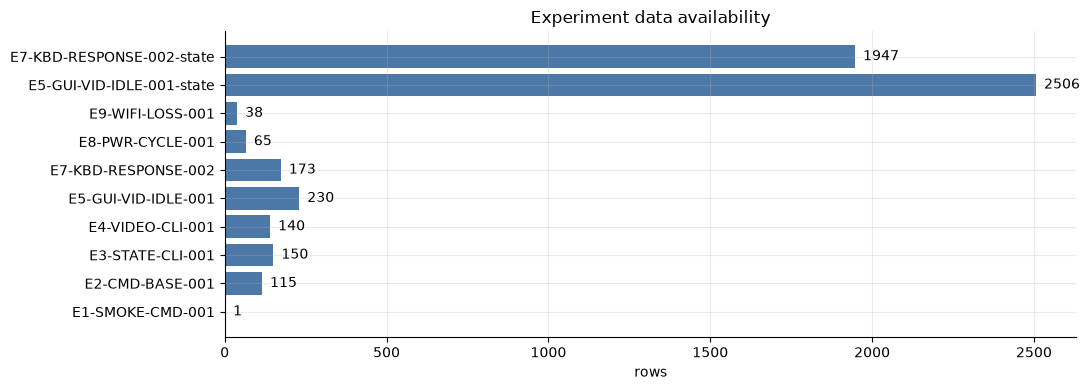

saved: notebooks/images/experiment_data_availability.png


In [228]:
labels = []
counts = []
for name, rows in list(metrics.items()) + list(states.items()):
    labels.append(name)
    counts.append(len(rows))

plt.figure(figsize=(11, max(4, len(labels) * 0.35)))
y = np.arange(len(labels))
plt.barh(y, counts, color="#4C78A8")
plt.yticks(y, labels)
plt.xlabel("rows")
plt.title("Experiment data availability")
for yi, c in zip(y, counts):
    plt.text(c + max(counts) * 0.01, yi, str(c), va="center")
savefig("experiment_data_availability.png")


## Run Summary

This table extracts the final row of each metrics file. It gives a compact view of duration, command failures, telemetry/video freshness labels, and final decode FPS. It is not a substitute for the detailed plots; it is only a run-level index.


In [229]:
columns = ["experiment", "rows", "duration_s", "cmd_failures", "telemetry", "video", "decode_fps"]
summary = []
for name, rows in metrics.items():
    duration_s = final_value(rows, "elapsed_ms", 0) / 1000.0
    summary.append([
        experiment_label(name),
        len(rows),
        f"{duration_s:.1f}",
        str(to_int(rows[-1].get("command_failures"), 0)) if rows else "0",
        final_text(rows, "telemetry_quality", ""),
        final_text(rows, "video_quality", ""),
        f"{final_value(rows, 'decoder_fps_ema', 0):.1f}",
    ])

widths = [max(len(str(row[i])) for row in [columns] + summary) for i in range(len(columns))]
fmt = " | ".join("{" + str(i) + ":" + str(widths[i]) + "}" for i in range(len(columns)))
print(fmt.format(*columns))
print("-+-".join("-" * w for w in widths))
for row in summary:
    print(fmt.format(*row))


experiment      | rows | duration_s | cmd_failures | telemetry | video   | decode_fps
----------------+------+------------+--------------+-----------+---------+-----------
E1-SMOKE-CMD    |    1 | 0.1        | 0            | NO_DATA   | NO_DATA | 0.0       
E2-CMD-BASE     |  115 | 121.6      | 0            | NO_DATA   | NO_DATA | 0.0       
E3-STATE-CLI    |  150 | 149.1      | 0            | OK        | NO_DATA | 0.0       
E4-VIDEO-CLI    |  140 | 181.0      | 0            | OK        | OK      | 31.3      
E5-GUI-VID-IDLE |  230 | 245.3      | 0            | OK        | OK      | 31.6      
E7-KBD-RESPONSE |  173 | 221.0      | 1            | OK        | OK      | 33.7      
E8-PWR-CYCLE    |   65 | 93.8       | 0            | OK        | OK      | 32.8      
E9-WIFI-LOSS    |   38 | 59.9       | 4            | NO_DATA   | NO_DATA | 0.0       


## Command Channel Evidence

The command baseline is analyzed with three complementary views. The cumulative average (`command_latency_ms_avg`) shows the run-level average seen by the metrics collector, but it can be distorted by a small number of long transient delays. The per-command latency view shows each `battery?` sample individually, making transient outliers visible. The filtered average excludes samples above 500 ms so the normal command-channel behavior can be read without the outliers dominating the scale.

In newer CSV files, per-command latency is read from `last_command_latency_ms`. For older CSV files, the notebook reconstructs each sample from the cumulative average and `command_samples`. Points above 500 ms are treated as outliers and are highlighted. These outliers do not necessarily mean the command failed; they mean the command took long enough to include a transient wait before eventually returning.

The command-stage timing fields split each command into client total time, SDK-mode check time, executor time, UDP send time, UDP receive wait time, response parsing time, accumulated UDP receive wait across all internal executor calls, command recovery time, number of executor calls, and number of recovery calls. The newer `command_internal_attempt_log` field preserves all internal executor calls and recovery calls made inside one high-level command. This matters because the final executor log can be overwritten by the last successful retry.

A recovered transient outage is classified as `TRANSIENT_LOSS_RECOVERED`: the command experienced at least one timeout/recovery internally, but the high-level API call returned `OK`. A real `LOST` event is reserved for cases where the command path remains unavailable after recovery.


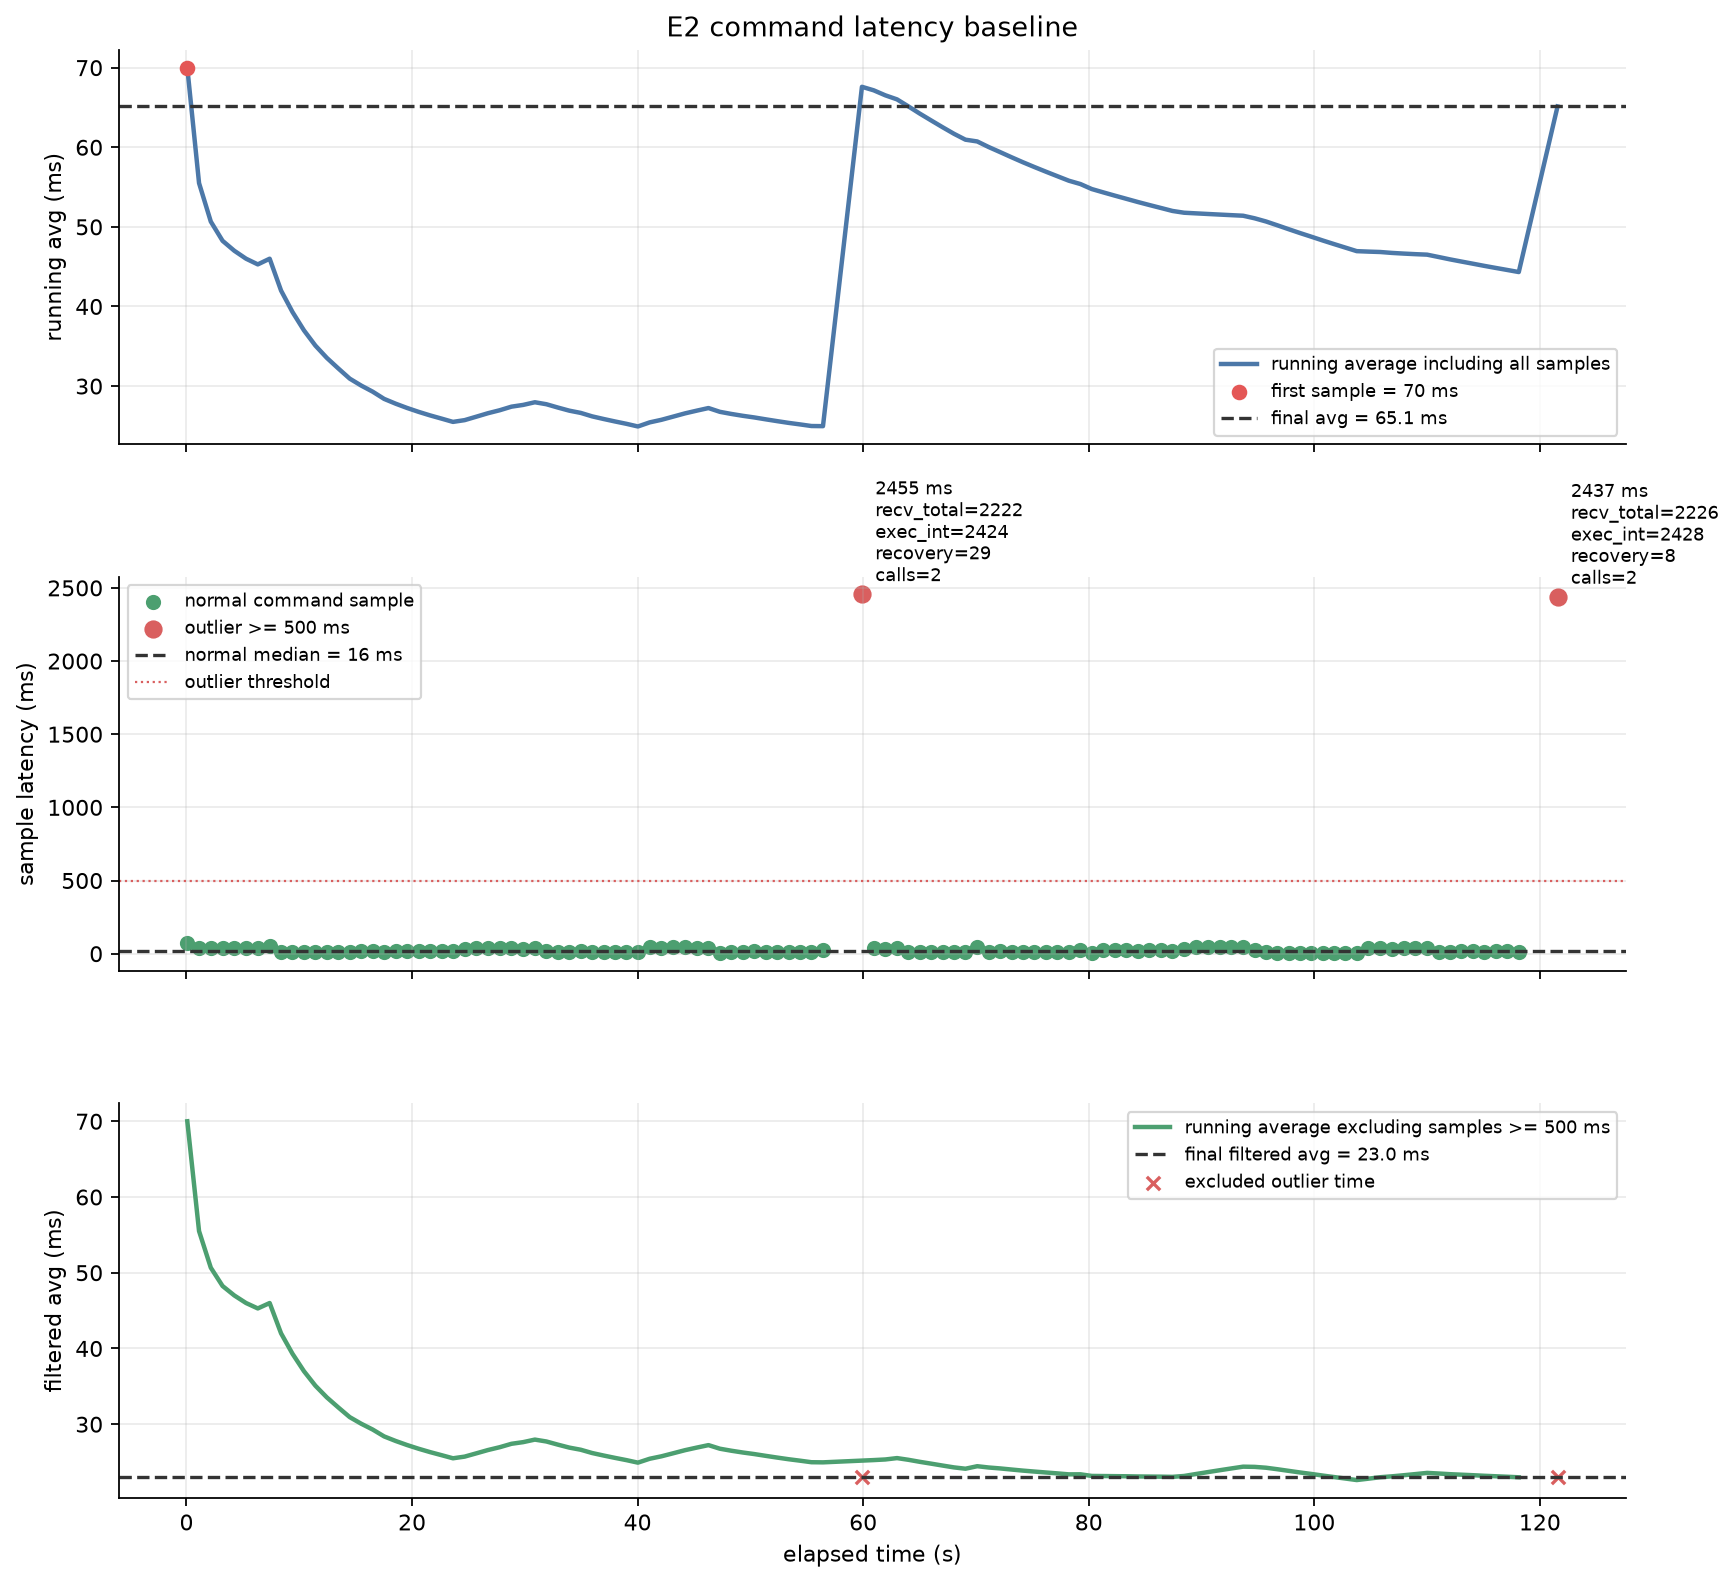

saved: notebooks/images/e2_command_latency.png
E2 per-command latency summary:
samples: 115
normal samples (<500 ms): 113 median=16 ms mean=23.0 ms p95=45 ms max=70 ms
final filtered running average: 23.0 ms
outliers >=500 ms:
  t=59.9s latency=2455 ms result=OK event=TRANSIENT_LOSS_RECOVERED attempts=4.0 retries=3.0 timeouts=3 client=2455.0 ensure=0.0 executor=2424.0 send=0.0 recv_last=48.0 parse=0.0 recv_total=2222.0 executor_internal=2424.0 recovery=29.0 executor_calls=2.0 recovery_count=1.0 source=last_command_latency_ms internal_log=executor_call=1|command=battery?|result=TIMEOUT|response=|elapsed_ms=2376|timing_total_ms=2376|recv_wait_ms=2174|attempt_log=[attempt=1|send=OK|raw=|result=TIMEOUT;attempt=2|send=O
  t=121.6s latency=2437 ms result=OK event=TRANSIENT_LOSS_RECOVERED attempts=4.0 retries=3.0 timeouts=3 client=2437.0 ensure=0.0 executor=2428.0 send=0.0 recv_last=50.0 parse=0.0 recv_total=2226.0 executor_internal=2428.0 recovery=8.0 executor_calls=2.0 recovery_count=1.0 so

In [230]:
def command_latency_samples(rows):
    samples = []
    has_last_latency = any("last_command_latency_ms" in row and row.get("last_command_latency_ms", "") != "" for row in rows)
    previous_samples = 0
    previous_total = 0.0
    for row in rows:
        t = to_float(row.get("elapsed_ms")) / 1000.0
        if math.isnan(t):
            continue
        result = row.get("last_command_result", "")
        event = row.get("event", "")
        attempts = to_float(row.get("command_attempt_count"), np.nan)
        retries = to_float(row.get("command_retry_count"), np.nan)
        internal_attempt_log = row.get("command_internal_attempt_log", "")
        timeouts = internal_attempt_log.count("raw=|result=TIMEOUT") if internal_attempt_log else to_float(row.get("command_timeout_count"), np.nan)
        source = "last_command_latency_ms"
        latency = to_float(row.get("last_command_latency_ms"), np.nan) if has_last_latency else np.nan
        if math.isnan(latency) or latency == 0:
            n = to_int(row.get("command_samples"), 0)
            avg = to_float(row.get("command_latency_ms_avg"), np.nan)
            if n > previous_samples and not math.isnan(avg):
                total = avg * n
                latency = (total - previous_total) / (n - previous_samples)
                source = "inferred_from_running_average"
                previous_samples = n
                previous_total = total
            elif n > 0 and not math.isnan(avg):
                previous_samples = n
                previous_total = avg * n
        if not math.isnan(latency):
            samples.append({
                "t": t,
                "latency": latency,
                "result": result,
                "event": event,
                "attempts": attempts,
                "retries": retries,
                "timeouts": timeouts,
                "client_total_ms": to_float(row.get("command_client_total_ms"), np.nan),
                "ensure_sdk_ms": to_float(row.get("command_ensure_sdk_ms"), np.nan),
                "executor_total_ms": to_float(row.get("command_executor_total_ms"), np.nan),
                "send_ms": to_float(row.get("command_send_ms"), np.nan),
                "recv_wait_ms": to_float(row.get("command_recv_wait_ms"), np.nan),
                "parse_ms": to_float(row.get("command_parse_ms"), np.nan),
                "executor_recv_wait_total_ms": to_float(row.get("command_executor_recv_wait_total_ms"), np.nan),
                "executor_internal_total_ms": to_float(row.get("command_executor_internal_total_ms"), np.nan),
                "recovery_ms": to_float(row.get("command_recovery_ms"), np.nan),
                "executor_calls": to_float(row.get("command_executor_calls"), np.nan),
                "recovery_count": to_float(row.get("command_recovery_count"), np.nan),
                "internal_attempt_log": internal_attempt_log,
                "source": source,
            })
    return samples

rows = get_rows("E2-CMD-BASE-001")
x_avg, y_avg = xy_series(rows, "command_latency_ms_avg", nonnegative=True)
samples = command_latency_samples(rows)
normal = [s for s in samples if s["latency"] < 500]
outliers = [s for s in samples if s["latency"] >= 500]

filtered_x = []
filtered_avg = []
running_total = 0.0
running_count = 0
for sample in samples:
    if sample["latency"] >= 500:
        continue
    running_total += sample["latency"]
    running_count += 1
    filtered_x.append(sample["t"])
    filtered_avg.append(running_total / running_count)

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
axes[0].plot(x_avg, y_avg, color="#4C78A8", linewidth=2, label="running average including all samples")
if len(y_avg):
    axes[0].scatter([x_avg[0]], [y_avg[0]], color="#E45756", zorder=5, label=f"first sample = {y_avg[0]:.0f} ms")
    axes[0].axhline(y_avg[-1], color="#333333", linestyle="--", label=f"final avg = {y_avg[-1]:.1f} ms")
axes[0].set_ylabel("running avg (ms)")
axes[0].set_title("E2 command latency baseline")
axes[0].legend(fontsize=8)

if normal:
    axes[1].scatter([s["t"] for s in normal], [s["latency"] for s in normal], color="#4C9F70", s=34, label="normal command sample")
if outliers:
    axes[1].scatter([s["t"] for s in outliers], [s["latency"] for s in outliers], color="#D95F5F", s=52, label="outlier >= 500 ms")
    for s in outliers:
        label = f"{s['latency']:.0f} ms"
        if not math.isnan(s["executor_recv_wait_total_ms"]):
            label += f"\nrecv_total={s['executor_recv_wait_total_ms']:.0f}"
        elif not math.isnan(s["recv_wait_ms"]):
            label += f"\nrecv={s['recv_wait_ms']:.0f}"
        if not math.isnan(s["executor_internal_total_ms"]):
            label += f"\nexec_int={s['executor_internal_total_ms']:.0f}"
        if not math.isnan(s["recovery_ms"]):
            label += f"\nrecovery={s['recovery_ms']:.0f}"
        if not math.isnan(s["executor_calls"]):
            label += f"\ncalls={int(s['executor_calls'])}"
        axes[1].annotate(label, (s["t"], s["latency"]), textcoords="offset points", xytext=(6, 6), fontsize=8)
if normal:
    normal_lat = np.array([s["latency"] for s in normal])
    axes[1].axhline(np.median(normal_lat), color="#333333", linestyle="--", label=f"normal median = {np.median(normal_lat):.0f} ms")
axes[1].axhline(500, color="#D95F5F", linestyle=":", linewidth=1, label="outlier threshold")
axes[1].set_ylabel("sample latency (ms)")
axes[1].legend(fontsize=8)

if filtered_avg:
    axes[2].plot(filtered_x, filtered_avg, color="#4C9F70", linewidth=2, label="running average excluding samples >= 500 ms")
    axes[2].axhline(filtered_avg[-1], color="#333333", linestyle="--", label=f"final filtered avg = {filtered_avg[-1]:.1f} ms")
if outliers:
    axes[2].scatter([s["t"] for s in outliers], [filtered_avg[-1] if filtered_avg else 0 for _ in outliers], color="#D95F5F", marker="x", label="excluded outlier time")
axes[2].set_xlabel("elapsed time (s)")
axes[2].set_ylabel("filtered avg (ms)")
axes[2].legend(fontsize=8)
savefig("e2_command_latency.png")

print("E2 per-command latency summary:")
if samples:
    print(f"samples: {len(samples)}")
if normal:
    normal_lat = np.array([s["latency"] for s in normal])
    print(f"normal samples (<500 ms): {len(normal)} median={np.median(normal_lat):.0f} ms mean={np.mean(normal_lat):.1f} ms p95={np.percentile(normal_lat, 95):.0f} ms max={np.max(normal_lat):.0f} ms")
if filtered_avg:
    print(f"final filtered running average: {filtered_avg[-1]:.1f} ms")
if outliers:
    print("outliers >=500 ms:")
    for s in outliers:
        print(
            f"  t={s['t']:.1f}s latency={s['latency']:.0f} ms result={s['result']} event={s['event']} "
            f"attempts={s['attempts']} retries={s['retries']} timeouts={s['timeouts']} "
            f"client={s['client_total_ms']} ensure={s['ensure_sdk_ms']} executor={s['executor_total_ms']} "
            f"send={s['send_ms']} recv_last={s['recv_wait_ms']} parse={s['parse_ms']} "
            f"recv_total={s['executor_recv_wait_total_ms']} executor_internal={s['executor_internal_total_ms']} "
            f"recovery={s['recovery_ms']} "
            f"executor_calls={s['executor_calls']} recovery_count={s['recovery_count']} source={s['source']} "
            f"internal_log={s['internal_attempt_log'][:180]}"
        )


### Transient Command Loss Diagnosis

The command-channel anomaly was investigated using two independent sources of evidence.

First, the latest E2 command baseline CSV contains 115 successful `battery?` commands and only two recovered transient outliers, near 59.9 s and 121.6 s. Both long samples were dominated by UDP receive wait time rather than GUI work, parsing, mutex wait, or CPU-side processing. They had `command_executor_recv_wait_total_ms` around 2.2 seconds, `command_executor_calls = 2`, `command_recovery_count = 1`, and final command result `OK`. That means the API sent a command, did not receive a response in time, performed recovery/retry, and then received a valid response.

Second, a packet capture was recorded with `tcpdump` while repeating the same experiment. The capture showed the same behavior at the UDP level: `battery?` packets left the computer, but the drone response either did not arrive before the SDK timeout or arrived too late. After recovery sent `command` again, the drone returned `ok`, and the next `battery?` received a normal response. This confirms that the delay was not caused by the API failing to read a response that had already arrived on time; the response was absent or late on the network path.

The practical interpretation is that these events are short transport outages in the command/response channel. The API recovered them correctly, but the previous label `LOST` was too alarmist because the high-level command completed successfully. The runtime now distinguishes this case as `TRANSIENT_LOSS_RECOVERED` and stores the full `command_internal_attempt_log` for post-run diagnosis.

The same transport behavior can affect RC commands differently. RC commands are sent as a continuous UDP stream and the panel uses a no-wait send path, so an individual RC packet is not acknowledged by the API. A single lost RC packet is usually harmless because the worker sends another packet shortly after. A longer outage is more important: if the last RC received by the drone was nonzero and neutral `rc 0 0 0 0` packets are delayed or lost, the drone may continue the previous motion until a new RC command is received. This is why the dedicated RC worker, stale-input neutral fallback, and high-priority neutral command on key release are safety-critical.


In [231]:
diagnostic_rows = []
for i, row in enumerate(get_rows("E2-CMD-BASE-001"), start=1):
    latency = to_float(row.get("last_command_latency_ms"), np.nan)
    executor_calls = to_float(row.get("command_executor_calls"), 0)
    recovery_count = to_float(row.get("command_recovery_count"), 0)
    internal_attempt_log = row.get("command_internal_attempt_log", "")
    timeout_count = internal_attempt_log.count("raw=|result=TIMEOUT") if internal_attempt_log else to_float(row.get("command_timeout_count"), 0)
    row["_timeout_attempt_count"] = str(timeout_count)
    event = row.get("event", "")
    if latency >= 500 or executor_calls > 1 or recovery_count > 0 or timeout_count > 0 or event not in ("", "NONE"):
        diagnostic_rows.append(row)

print("Recovered transient command-channel evidence in the current E2 CSV, if present:")
print("elapsed_s | event | result | latency_ms | recv_wait_total_ms | recovery_ms | executor_calls | recovery_count | timeouts")
if diagnostic_rows:
    for row in diagnostic_rows:
        print(
            f"{to_float(row.get('elapsed_ms'))/1000.0:8.3f} | "
            f"{row.get('event',''):24} | "
            f"{row.get('last_command_result',''):6} | "
            f"{to_float(row.get('last_command_latency_ms')):10.0f} | "
            f"{to_float(row.get('command_executor_recv_wait_total_ms')):18.0f} | "
            f"{to_float(row.get('command_recovery_ms')):11.0f} | "
            f"{to_float(row.get('command_executor_calls')):14.0f} | "
            f"{to_float(row.get('command_recovery_count')):14.0f} | "
            f"{to_float(row.get('_timeout_attempt_count')):8.0f}"
        )
        internal = row.get("command_internal_attempt_log", "")
        if internal:
            print("  internal:", internal[:260] + ("..." if len(internal) > 260 else ""))
else:
    print("No transient command-loss rows are present in the current E2 CSV file.")
    print("The table below records the representative tcpdump diagnostic run used for the report discussion.")

print("\nCurrent E2 recovered transient events:")
print("elapsed_s | event | result | latency_ms | recv_wait_total_ms | recovery_ms | executor_calls | recovery_count | packet-capture/API observation")
representative = [
    (59.889, "TRANSIENT_LOSS_RECOVERED", "OK", 2455, 2222, 29, 2, 1, "three battery? attempts timed out; command recovery ok; retry battery? succeeded"),
    (121.566, "TRANSIENT_LOSS_RECOVERED", "OK", 2437, 2226, 8, 2, 1, "three battery? attempts timed out; command recovery ok; retry battery? succeeded"),
]
for row in representative:
    print(f"{row[0]:8.3f} | {row[1]:24} | {row[2]:6} | {row[3]:10} | {row[4]:18} | {row[5]:11} | {row[6]:14} | {row[7]:14} | {row[8]}")

print("\nExternal packet-capture confirmation:")
print("A previous tcpdump run of the same periodic pattern showed battery? packets leaving the computer while the drone response was absent or late, followed by successful SDK recovery and a normal next battery? response.")

print("\nInterpretation:")
print("- The high latency is dominated by UDP receive wait, not GUI, parsing, or mutex delay.")
print("- The packet capture confirms that battery? responses were absent or late on the UDP path.")
print("- The API recovered correctly; the new event label for this case is TRANSIENT_LOSS_RECOVERED.")
print("- RC commands can be affected silently because no-wait RC sends are not acknowledged per packet.")


Recovered transient command-channel evidence in the current E2 CSV, if present:
elapsed_s | event | result | latency_ms | recv_wait_total_ms | recovery_ms | executor_calls | recovery_count | timeouts
  59.889 | TRANSIENT_LOSS_RECOVERED | OK     |       2455 |               2222 |          29 |              2 |              1 |        3
  internal: executor_call=1|command=battery?|result=TIMEOUT|response=|elapsed_ms=2376|timing_total_ms=2376|recv_wait_ms=2174|attempt_log=[attempt=1|send=OK|raw=|result=TIMEOUT;attempt=2|send=OK|raw=|result=TIMEOUT;attempt=3|send=OK|raw=|result=TIMEOUT];recovery_call=1|res...
 121.566 | TRANSIENT_LOSS_RECOVERED | OK     |       2437 |               2226 |           8 |              2 |              1 |        3
  internal: executor_call=1|command=battery?|result=TIMEOUT|response=|elapsed_ms=2378|timing_total_ms=2378|recv_wait_ms=2176|attempt_log=[attempt=1|send=OK|raw=|result=TIMEOUT;attempt=2|send=OK|raw=|result=TIMEOUT;attempt=3|send=OK|raw=|result=TIME

## Telemetry Freshness

Telemetry freshness is determined from two timing values: latest packet age and packet interarrival time. The score is not a semantic correctness score; it says whether telemetry is fresh enough to trust for monitoring or future feedback control.

- `packet age` is how old the most recently received telemetry packet is at the moment the metrics row is written. If no new packet arrives, age grows.
- `packet interarrival` is the time gap between consecutive telemetry packets. It shows whether packets are arriving regularly.

A run can have low interarrival while packets are flowing, then high age after packets stop. For telemetry to be `OK`, both the latest age and interarrival constraints must be satisfied.

Quality thresholds used by the project:

- `OK = 100`: latest telemetry age <= 200 ms and interarrival <= 300 ms.
- `DEGRADED = 60`: latest telemetry age <= 500 ms and interarrival <= 500 ms.
- `STALE = 0`: data is older than those limits.
- `NO_DATA = 0`: no telemetry packet was received.


The boxplot keeps the distribution view. It answers: how much did telemetry age vary during each run? Lower is better; values near or above 500 ms mean the current state is too old for feedback assumptions.


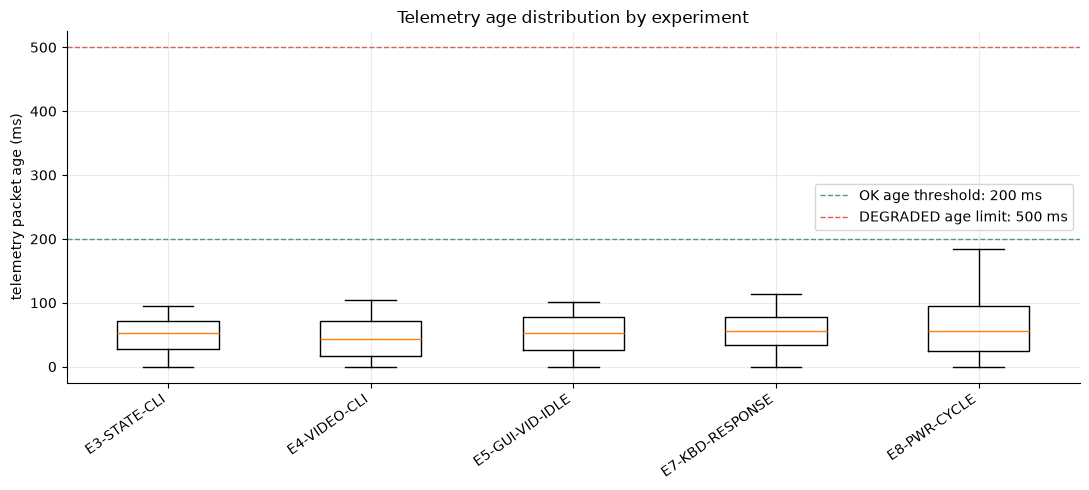

saved: notebooks/images/telemetry_age_comparison.png


In [232]:
labels = []
values = []
for name, rows in metrics.items():
    ages = series(rows, "telemetry_age_ms", nonnegative=True)
    if len(ages):
        labels.append(experiment_label(name))
        values.append(ages)

plt.figure(figsize=(11, 5))
plt.boxplot(values, tick_labels=labels, showfliers=False)
plt.axhline(200, color="#4C9F70", linestyle="--", linewidth=1, label="OK age threshold: 200 ms")
plt.axhline(500, color="#D95F5F", linestyle="--", linewidth=1, label="DEGRADED age limit: 500 ms")
plt.xticks(rotation=35, ha="right")
plt.ylabel("telemetry packet age (ms)")
plt.title("Telemetry age distribution by experiment")
plt.legend()
savefig("telemetry_age_comparison.png")


The timeline view makes the freshness rule visible over time. The first two subplots compare normal runs up to 150 seconds. E8 power-cycle is separated into its own two subplots because powering the drone off intentionally creates a very large age spike; if plotted on the same axis, it hides the behavior of the other runs.

The age plot answers: how old is the latest known state right now? The interarrival plot answers: while packets are arriving, how regular is the stream?


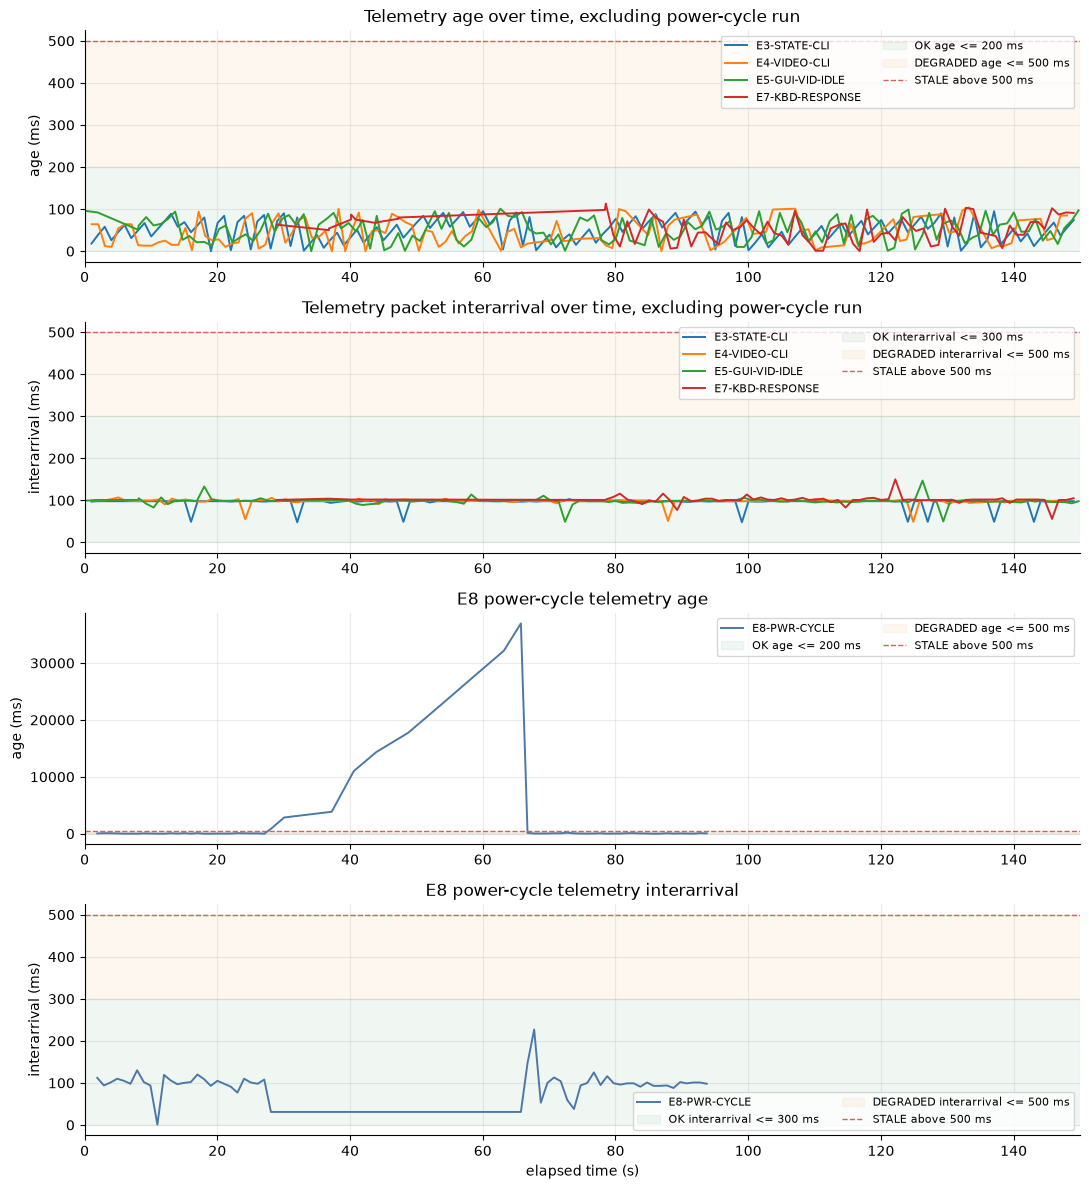

saved: notebooks/images/telemetry_freshness_timeline.png


In [233]:
telemetry_runs = ["E3-STATE-CLI-001", "E4-VIDEO-CLI-001", "E5-GUI-VID-IDLE-001", "E7-KBD-RESPONSE-002"]
power_run = "E8-PWR-CYCLE-001"
fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=False)

def decorate_age_axis(ax, title):
    ax.axhspan(0, 200, color="#4C9F70", alpha=0.08, label="OK age <= 200 ms")
    ax.axhspan(200, 500, color="#E6A23C", alpha=0.08, label="DEGRADED age <= 500 ms")
    ax.axhline(500, color="#D95F5F", linestyle="--", linewidth=1, label="STALE above 500 ms")
    ax.set_ylabel("age (ms)")
    ax.set_title(title)

def decorate_interarrival_axis(ax, title):
    ax.axhspan(0, 300, color="#4C9F70", alpha=0.08, label="OK interarrival <= 300 ms")
    ax.axhspan(300, 500, color="#E6A23C", alpha=0.08, label="DEGRADED interarrival <= 500 ms")
    ax.axhline(500, color="#D95F5F", linestyle="--", linewidth=1, label="STALE above 500 ms")
    ax.set_ylabel("interarrival (ms)")
    ax.set_title(title)

for name in telemetry_runs:
    rows = get_rows(name)
    x_age, age = xy_series(rows, "telemetry_age_ms", nonnegative=True, max_s=150)
    x_int, inter = xy_series(rows, "telemetry_interarrival_ms", nonnegative=True, max_s=150)
    axes[0].plot(x_age, age, linewidth=1.4, label=experiment_label(name))
    axes[1].plot(x_int, inter, linewidth=1.4, label=experiment_label(name))

rows = get_rows(power_run)
x_age, age = xy_series(rows, "telemetry_age_ms", nonnegative=True, max_s=150)
x_int, inter = xy_series(rows, "telemetry_interarrival_ms", nonnegative=True, max_s=150)
axes[2].plot(x_age, age, linewidth=1.4, color="#4C78A8", label=experiment_label(power_run))
axes[3].plot(x_int, inter, linewidth=1.4, color="#4C78A8", label=experiment_label(power_run))

decorate_age_axis(axes[0], "Telemetry age over time, excluding power-cycle run")
decorate_interarrival_axis(axes[1], "Telemetry packet interarrival over time, excluding power-cycle run")
decorate_age_axis(axes[2], "E8 power-cycle telemetry age")
decorate_interarrival_axis(axes[3], "E8 power-cycle telemetry interarrival")
for ax in axes:
    ax.set_xlim(0, 150)
    ax.legend(fontsize=8, ncol=2)
axes[3].set_xlabel("elapsed time (s)")
savefig("telemetry_freshness_timeline.png")


## Video Pipeline Performance

The project uses FFmpeg Stream as the only video runtime path. Decode FPS is the main practical indicator of whether the video pipeline is keeping up with the stream. This comparison is capped at 150 seconds so longer runs do not dominate the visual scale.


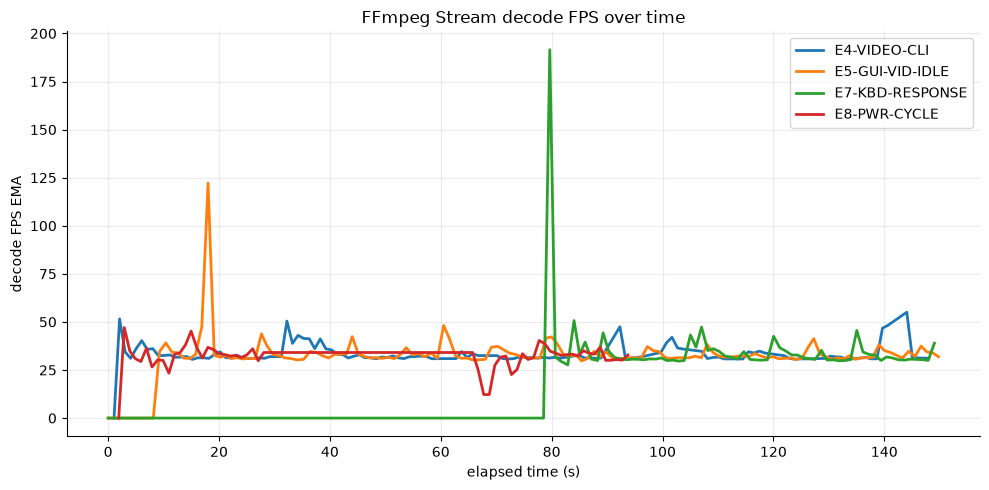

saved: notebooks/images/video_decode_fps_comparison.png


In [234]:
video_runs = [name for name in metrics if len(series(metrics[name], "decoder_fps_ema", nonzero=True)) > 0]
plt.figure(figsize=(10, 5))
for name in video_runs:
    rows = metrics[name]
    x, fps = xy_series(rows, "decoder_fps_ema", nonnegative=True, max_s=150)
    if len(fps):
        plt.plot(x, fps, linewidth=2, label=experiment_label(name))
plt.xlabel("elapsed time (s)")
plt.ylabel("decode FPS EMA")
plt.title("FFmpeg Stream decode FPS over time")
plt.legend()
savefig("video_decode_fps_comparison.png")


Video quality uses the same freshness concept as telemetry quality. It is not a subjective video sharpness score. A score of 100 means recent decoded video data is arriving within the freshness thresholds; 60 means delayed but present; 0 means stale or missing.


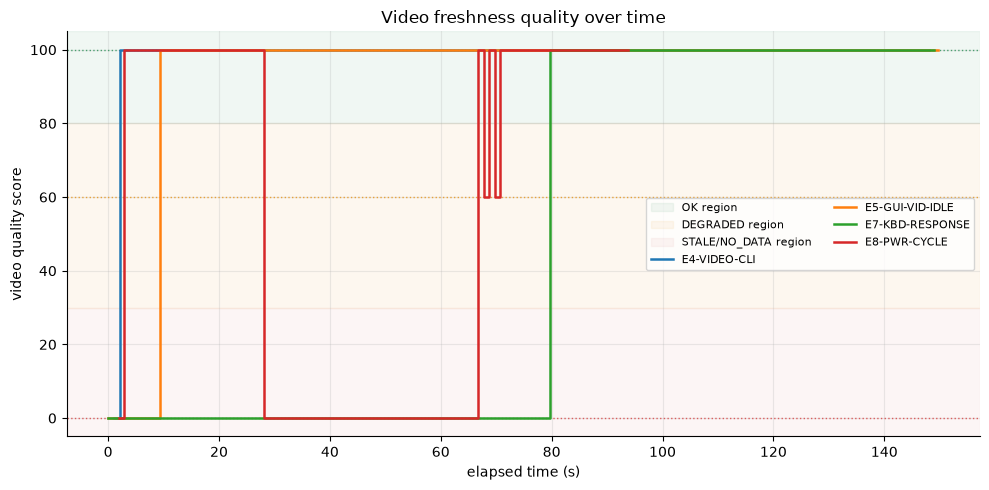

saved: notebooks/images/video_quality_comparison.png


In [235]:
fig, ax = plt.subplots(figsize=(10, 5))
add_quality_bands(ax)
for name in video_runs:
    rows = get_rows(name)
    x, q = xy_series(rows, "video_quality_score", nonnegative=True, max_s=150)
    if len(q):
        ax.step(x, q, where="post", linewidth=1.8, label=experiment_label(name))
ax.set_xlabel("elapsed time (s)")
ax.set_ylabel("video quality score")
ax.set_title("Video freshness quality over time")
ax.legend(fontsize=8, ncol=2)
savefig("video_quality_comparison.png")


## GUI Responsiveness

This comparison shows Qt timer delays over time. The reference lines are the intended timer periods: about 120 ms for the vision refresh timer and about 250 ms for the state/plot refresh timer.

A spike would mean the timer callback ran late. In practical terms, Qt wanted to execute a GUI update at the expected time, but the GUI event loop did not get CPU time until later. Possible causes include GUI-thread rendering work, blocking SDK calls, OS scheduling pauses, graphics/driver stalls, or contention with shared frame/state data.

The repeated E7 keyboard-flight run is used here to check whether moving critical commands to a background worker fixed the takeoff/land stalls observed earlier. In this run, the GUI timers remain close to their expected periods and `command_mutex_wait_ms` stays at zero, which indicates that the GUI event loop was no longer blocked by the critical command path. The takeoff command still timed out at the SDK response layer, but the timeout no longer froze the panel. Land returned `OK`.


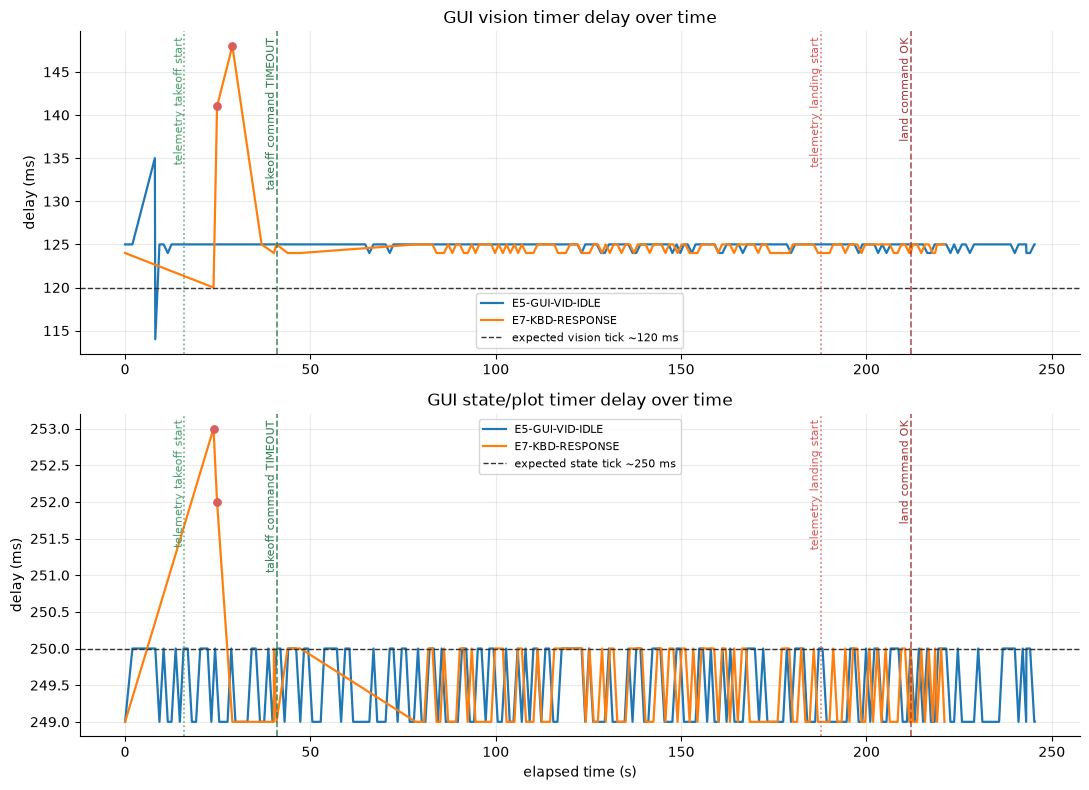

saved: notebooks/images/gui_tick_delay_idle_vs_flight.png
GUI tick delay summary (ms):
experiment | timer | median | p95 | max
E5-GUI-VID-IDLE | vision | 125 | 125 | 135
E5-GUI-VID-IDLE | state | 249 | 250 | 250
E7-KBD-RESPONSE | vision | 125 | 125 | 148
E7-KBD-RESPONSE | state | 249 | 250 | 253

Largest highlighted E7 points:
state: t=23.9s delay=253ms
state: t=24.8s delay=252ms
vision: t=28.9s delay=148ms
vision: t=24.8s delay=141ms

E7-002 critical command check:
takeoff command: t=40.9s result=TIMEOUT response=none critical_ms=704
land command:    t=211.9s result=OK response=ok critical_ms=0
telemetry takeoff marker: 16.0s; telemetry landing marker: 187.7s
command_mutex_wait_ms: median=0, p95=0, max=0
Interpretation: GUI timer delays stayed near the intended periods, so the previous takeoff/land GUI stall was mitigated. The SDK takeoff acknowledgement still timed out in this recording; land returned OK.


In [236]:
gui_runs = ["E5-GUI-VID-IDLE-001", "E7-KBD-RESPONSE-002"]
e7_state_rows = get_state("E7-KBD-RESPONSE-002-state")
e7_metric_rows = get_rows("E7-KBD-RESPONSE-002")
e7_takeoff_physical_s, e7_land_physical_s, _ = physical_flight_markers(e7_state_rows)

def command_event_info(rows, command):
    for row in rows:
        if row.get("event") == "command:manual" and row.get("last_command") == command:
            return {
                "time_s": to_float(row.get("elapsed_ms")) / 1000.0,
                "result": row.get("last_command_result", ""),
                "response": row.get("last_response", ""),
                "critical_ms": to_float(row.get("critical_command_ms"), 0),
            }
    return {"time_s": np.nan, "result": "", "response": "", "critical_ms": np.nan}

takeoff_event = command_event_info(e7_metric_rows, "takeoff")
land_event = command_event_info(e7_metric_rows, "land")
e7_takeoff_log_s = takeoff_event["time_s"]
e7_land_log_s = land_event["time_s"]

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)
summary_rows = []
spike_rows = []

def top_unique_spikes(x, y, limit=2):
    candidates = sorted(zip(x, y), key=lambda item: item[1], reverse=True)
    selected = []
    seen = set()
    for t, value in candidates:
        key = round(float(t), 1)
        if key in seen:
            continue
        seen.add(key)
        selected.append((float(t), float(value)))
        if len(selected) >= limit:
            break
    return selected

def annotate_gui_event_markers(ax):
    markers = [
        (e7_takeoff_physical_s, "telemetry takeoff start", "#4C9F70", ":"),
        (e7_takeoff_log_s, f"takeoff command {takeoff_event['result']}", "#2F7D4F", "--"),
        (e7_land_physical_s, "telemetry landing start", "#D95F5F", ":"),
        (e7_land_log_s, f"land command {land_event['result']}", "#A33A3A", "--"),
    ]
    for t, label, color, style in markers:
        if not math.isnan(t):
            ax.axvline(t, color=color, linestyle=style, linewidth=1.2, alpha=0.85)
            ax.text(t, 0.98, label, transform=ax.get_xaxis_transform(), rotation=90, va="top", ha="right", fontsize=8, color=color)

for name in gui_runs:
    rows = get_rows(name)
    label = experiment_label(name)
    x_v, vision = xy_series(rows, "gui_vision_tick_delay_ms", nonnegative=True)
    x_s, state = xy_series(rows, "gui_state_tick_delay_ms", nonnegative=True)
    axes[0].plot(x_v, vision, label=label, linewidth=1.6)
    axes[1].plot(x_s, state, label=label, linewidth=1.6)
    if name.startswith("E7"):
        for ax, x, y, timer in [(axes[0], x_v, vision, "vision"), (axes[1], x_s, state, "state")]:
            spikes = top_unique_spikes(x, y, limit=2)
            if spikes:
                sx = np.array([item[0] for item in spikes])
                sy = np.array([item[1] for item in spikes])
                ax.scatter(sx, sy, color="#D95F5F", zorder=5, s=28)
                for t, value in spikes:
                    spike_rows.append((timer, t, value))
    if len(vision):
        summary_rows.append((label, "vision", np.median(vision), np.percentile(vision, 95), np.max(vision)))
    if len(state):
        summary_rows.append((label, "state", np.median(state), np.percentile(state, 95), np.max(state)))

axes[0].axhline(120, color="#333333", linestyle="--", linewidth=1, label="expected vision tick ~120 ms")
axes[0].set_title("GUI vision timer delay over time")
axes[0].set_ylabel("delay (ms)")
axes[0].legend(fontsize=8)
axes[1].axhline(250, color="#333333", linestyle="--", linewidth=1, label="expected state tick ~250 ms")
axes[1].set_title("GUI state/plot timer delay over time")
axes[1].set_ylabel("delay (ms)")
axes[1].set_xlabel("elapsed time (s)")
axes[1].legend(fontsize=8)
for ax in axes:
    annotate_gui_event_markers(ax)
savefig("gui_tick_delay_idle_vs_flight.png")

mutex_wait = series(e7_metric_rows, "command_mutex_wait_ms", nonnegative=True)
print("GUI tick delay summary (ms):")
print("experiment | timer | median | p95 | max")
for label, timer, median, p95, max_v in summary_rows:
    print(f"{label} | {timer} | {median:.0f} | {p95:.0f} | {max_v:.0f}")
print("\nLargest highlighted E7 points:")
for timer, t, value in sorted(spike_rows, key=lambda item: item[2], reverse=True):
    print(f"{timer}: t={t:.1f}s delay={value:.0f}ms")
print("\nE7-002 critical command check:")
print(f"takeoff command: t={e7_takeoff_log_s:.1f}s result={takeoff_event['result']} response={takeoff_event['response'] or 'none'} critical_ms={takeoff_event['critical_ms']:.0f}")
print(f"land command:    t={e7_land_log_s:.1f}s result={land_event['result']} response={land_event['response'] or 'none'} critical_ms={land_event['critical_ms']:.0f}")
print(f"telemetry takeoff marker: {e7_takeoff_physical_s:.1f}s; telemetry landing marker: {e7_land_physical_s:.1f}s")
if len(mutex_wait):
    print(f"command_mutex_wait_ms: median={np.median(mutex_wait):.0f}, p95={np.percentile(mutex_wait, 95):.0f}, max={np.max(mutex_wait):.0f}")
print("Interpretation: GUI timer delays stayed near the intended periods, so the previous takeoff/land GUI stall was mitigated. The SDK takeoff acknowledgement still timed out in this recording; land returned OK.")


## State Recording And Thermal Context

State inter-sample gap is the elapsed time between two consecutive rows in the state recording CSV. It is a continuity metric for telemetry recording. If the receiver/logger is getting state packets regularly, the gaps stay close to the expected packet period. Large gaps mean one of three things happened: telemetry packets were not received, the receiver thread was delayed, or the recording path did not write a state sample on time.


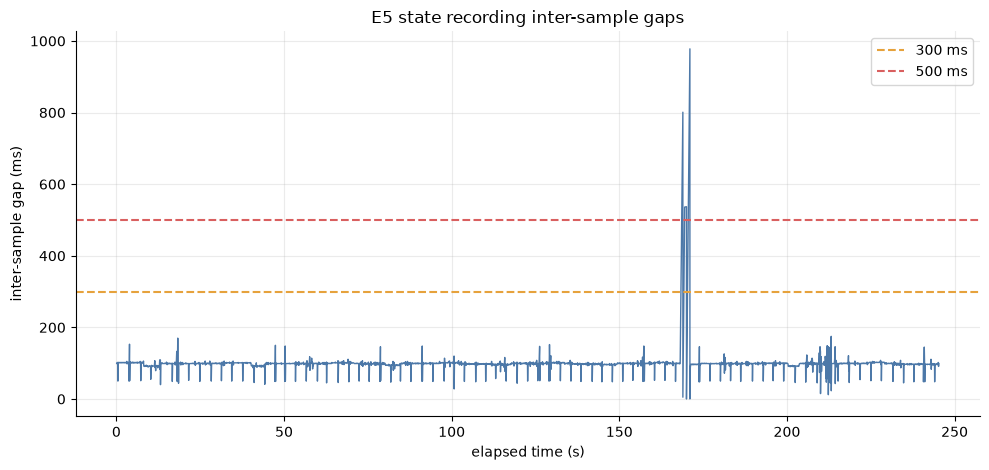

saved: notebooks/images/e5_state_gaps.png


In [237]:
def plot_state_gaps(state_name, image_name, title):
    rows = get_state(state_name)
    t = series(rows, "steady_elapsed_ms", nonnegative=True)
    gaps = np.diff(t)
    gap_t = t[1:] / 1000.0
    plt.figure(figsize=(10, 4.8))
    plt.plot(gap_t, gaps, color="#4C78A8", linewidth=1)
    plt.axhline(300, color="#E6A23C", linestyle="--", label="300 ms")
    plt.axhline(500, color="#D95F5F", linestyle="--", label="500 ms")
    plt.xlabel("elapsed time (s)")
    plt.ylabel("inter-sample gap (ms)")
    plt.title(title)
    plt.legend()
    savefig(image_name)

plot_state_gaps("E5-GUI-VID-IDLE-001-state", "e5_state_gaps.png", "E5 state recording inter-sample gaps")


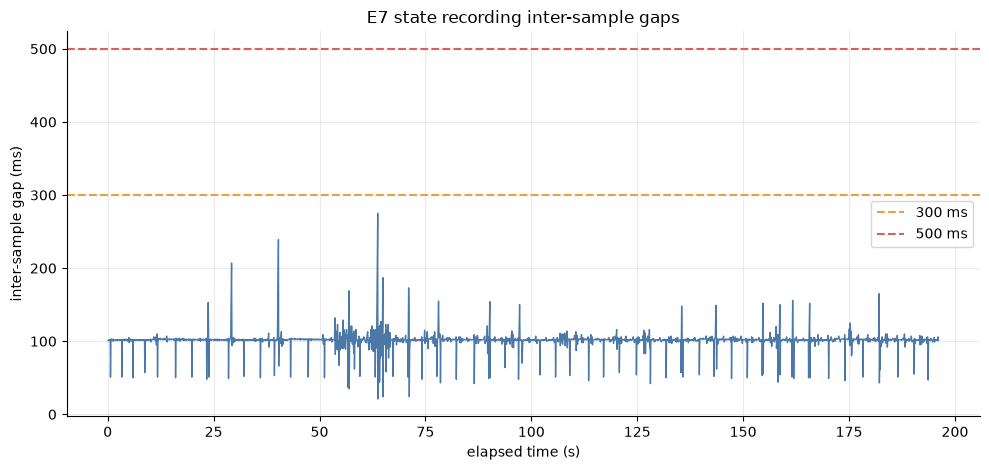

saved: notebooks/images/e7_state_gaps.png


In [238]:
plot_state_gaps("E7-KBD-RESPONSE-002-state", "e7_state_gaps.png", "E7 state recording inter-sample gaps")


Temperature is included because the Tello can become thermally constrained during long or repeated runs. `templ` and `temph` are the low/high internal temperature readings reported by the SDK.


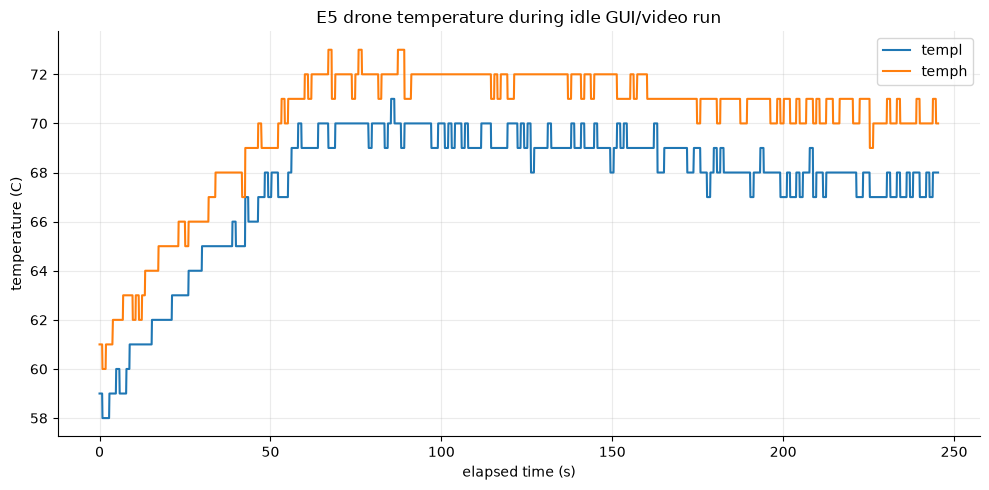

saved: notebooks/images/e5_temperature.png


In [239]:
rows = get_state("E5-GUI-VID-IDLE-001-state")
x = series(rows, "steady_elapsed_ms", nonnegative=True) / 1000.0
plt.figure(figsize=(10, 5))
plt.plot(x, series(rows, "templ"), label="templ")
plt.plot(x, series(rows, "temph"), label="temph")
plt.xlabel("elapsed time (s)")
plt.ylabel("temperature (C)")
plt.title("E5 drone temperature during idle GUI/video run")
plt.legend()
savefig("e5_temperature.png")


## Keyboard Flight Operation

The keyboard experiment combines flight, telemetry, video, GUI rendering, and RC command generation. The next plot separates physical height from the vertical RC command so it is clear when the operator requested upward or downward motion.

The takeoff and landing markers in this plot are estimated from telemetry, not from the delayed `command:manual` log rows. The command rows are written after the blocking command call finishes, which can be several seconds late when the command times out. The physical takeoff marker is the first sustained increase in `h`/`tof`; the landing marker is the beginning of the final sustained descent toward the ground.


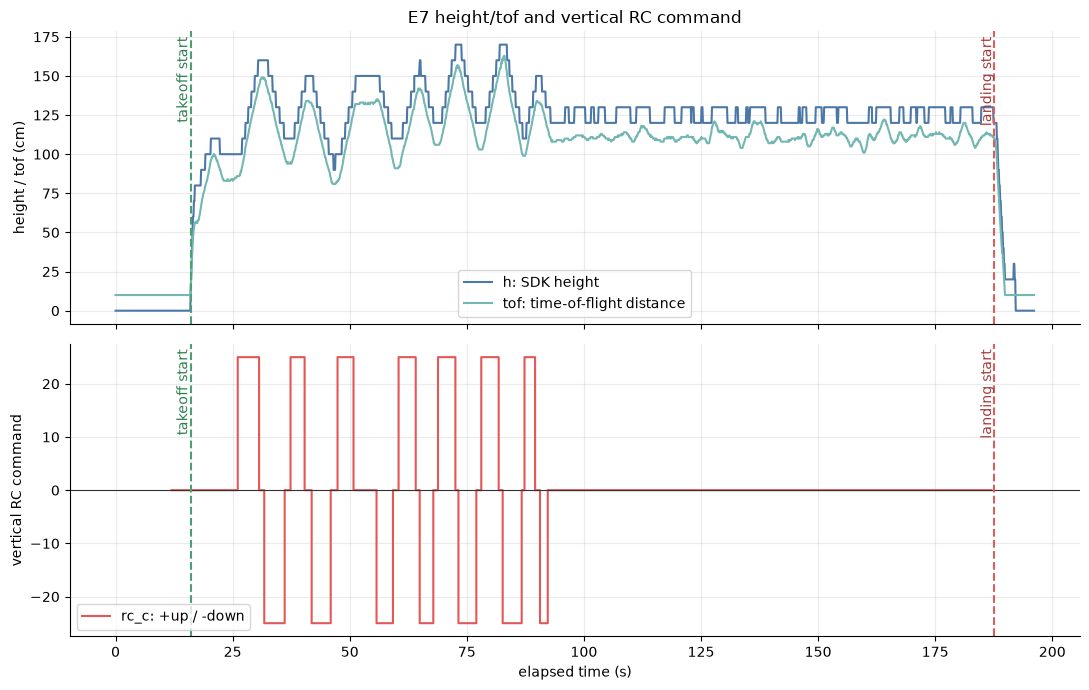

saved: notebooks/images/e7_height_and_vertical_rc.png
physical takeoff start marker: 16.0 s
physical landing start marker: 187.7 s
touchdown marker estimate: 192.2 s


In [240]:
state_rows = get_state("E7-KBD-RESPONSE-002-state")
takeoff_s, land_s, touchdown_s = physical_flight_markers(state_rows)

x = series(state_rows, "steady_elapsed_ms", nonnegative=True) / 1000.0
h = series(state_rows, "h")
tof = series(state_rows, "tof")
cmds_by_seq = OrderedDict()
for r in state_rows:
    seq = r.get("rc_sequence", "")
    if seq and seq not in cmds_by_seq:
        cmds_by_seq[seq] = r
cmds = list(cmds_by_seq.values())
rt = np.array([to_float(r.get("rc_steady_elapsed_ms")) / 1000.0 for r in cmds])
rc_c = np.array([to_float(r.get("rc_c"), 0) for r in cmds])

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(x[:len(h)], h, label="h: SDK height", color="#4C78A8")
axes[0].plot(x[:len(tof)], tof, label="tof: time-of-flight distance", color="#72B7B2")
axes[0].set_ylabel("height / tof (cm)")
axes[0].set_title("E7 height/tof and vertical RC command")
axes[0].legend()
axes[1].step(rt, rc_c, where="post", color="#E45756", label="rc_c: +up / -down")
axes[1].axhline(0, color="#333333", linewidth=0.8)
axes[1].set_ylabel("vertical RC command")
axes[1].set_xlabel("elapsed time (s)")
axes[1].legend()
for ax in axes:
    annotate_takeoff_land(ax, takeoff_s, land_s)
savefig("e7_height_and_vertical_rc.png")
print(f"physical takeoff start marker: {takeoff_s:.1f} s")
print(f"physical landing start marker: {land_s:.1f} s")
print(f"touchdown marker estimate: {touchdown_s:.1f} s")


The RC channel plot shows all four RC axes sent by the keyboard worker. Positive/negative values represent direction along each SDK control channel.


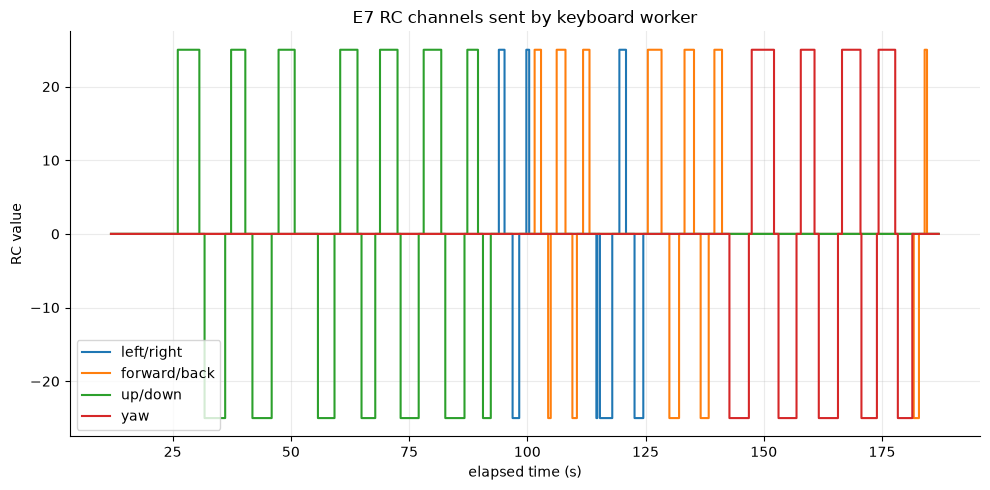

saved: notebooks/images/e7_rc_channels.png


In [241]:
plt.figure(figsize=(10, 5))
for col, label in [("rc_a", "left/right"), ("rc_b", "forward/back"), ("rc_c", "up/down"), ("rc_d", "yaw")]:
    vals = np.array([to_float(r.get(col), 0) for r in cmds])
    plt.step(rt, vals, where="post", label=label)
plt.xlabel("elapsed time (s)")
plt.ylabel("RC value")
plt.title("E7 RC channels sent by keyboard worker")
plt.legend()
savefig("e7_rc_channels.png")


The RC cadence plot focuses on the active worker cadence. The raw data contains one long inactive gap of about 21.7 seconds, which would stretch the histogram and hide the useful behavior. Therefore the histogram caps the displayed range at 250 ms and annotates the excluded long gap separately.


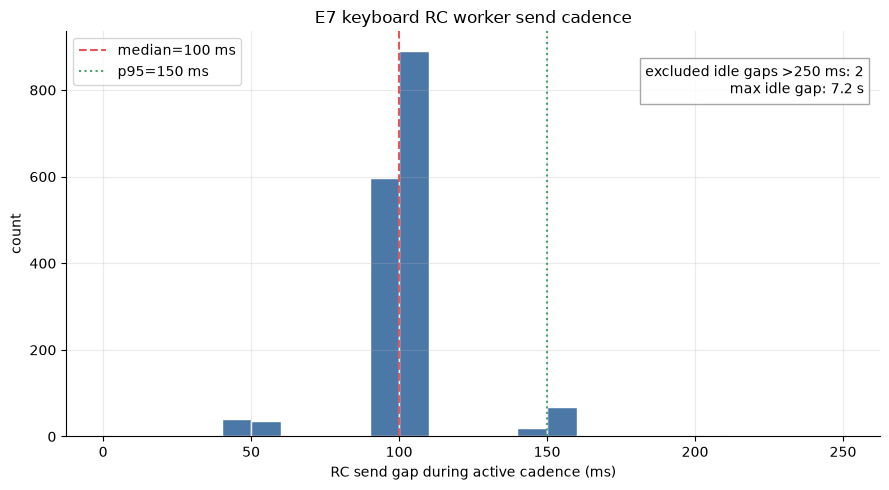

saved: notebooks/images/e7_rc_gap_histogram.png


In [242]:
gaps = np.diff(rt) * 1000.0 if len(rt) > 1 else np.array([])
active_gaps = gaps[gaps <= 250]
long_gaps = gaps[gaps > 250]
plt.figure(figsize=(9, 5))
if len(active_gaps):
    plt.hist(active_gaps, bins=np.arange(0, 260, 10), color="#4C78A8", edgecolor="white")
    median = np.median(active_gaps)
    p95 = np.percentile(active_gaps, 95)
    plt.axvline(median, color="#E45756", linestyle="--", label=f"median={median:.0f} ms")
    plt.axvline(p95, color="#4C9F70", linestyle=":", label=f"p95={p95:.0f} ms")
plt.xlabel("RC send gap during active cadence (ms)")
plt.ylabel("count")
plt.title("E7 keyboard RC worker send cadence")
if len(long_gaps):
    plt.text(0.98, 0.92, f"excluded idle gaps >250 ms: {len(long_gaps)}\nmax idle gap: {np.max(long_gaps)/1000:.1f} s", transform=plt.gca().transAxes, ha="right", va="top", bbox=dict(facecolor="white", alpha=0.85, edgecolor="#999"))
plt.legend()
savefig("e7_rc_gap_histogram.png")


The operation quality plot combines telemetry/video freshness and decode FPS during keyboard flight. Quality score again means freshness/continuity: 100 is OK, 60 is degraded, and 0 is stale or no data.


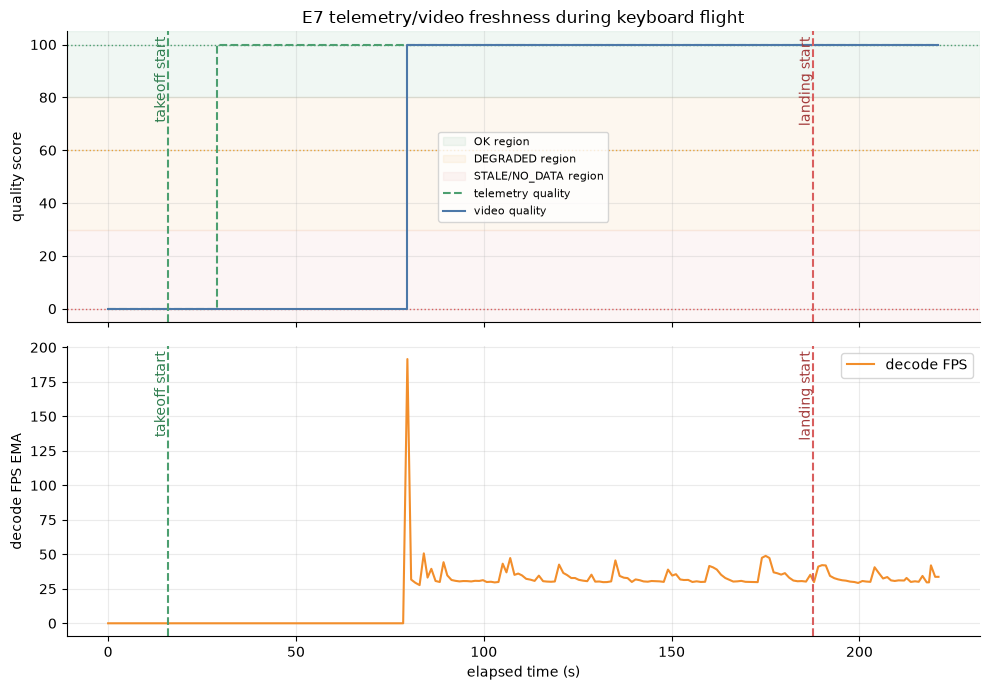

saved: notebooks/images/e7_operation_quality_video.png


In [243]:
rows = get_rows("E7-KBD-RESPONSE-002")
state_rows = get_state("E7-KBD-RESPONSE-002-state")
takeoff_s, land_s, _ = physical_flight_markers(state_rows)
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
add_quality_bands(axes[0])
x_t, tq = xy_series(rows, "telemetry_quality_score", nonnegative=True)
x_v, vq = xy_series(rows, "video_quality_score", nonnegative=True)
axes[0].step(x_t, tq, where="post", label="telemetry quality", color="#4C9F70", linestyle="--")
axes[0].step(x_v, vq, where="post", label="video quality", color="#4C78A8")
axes[0].set_ylabel("quality score")
axes[0].legend(fontsize=8)
axes[0].set_title("E7 telemetry/video freshness during keyboard flight")
x_fps, fps = xy_series(rows, "decoder_fps_ema", nonnegative=True)
axes[1].plot(x_fps, fps, color="#F28E2B", label="decode FPS")
axes[1].set_ylabel("decode FPS EMA")
axes[1].set_xlabel("elapsed time (s)")
axes[1].legend()
for ax in axes:
    annotate_takeoff_land(ax, takeoff_s, land_s)
savefig("e7_operation_quality_video.png")


### RC Response Latency Estimate

The repeated keyboard-flight run is used to estimate how long it took telemetry to show a response after a nonzero RC command. Each point in the next plot is one detected RC pulse.

Different channels require different telemetry proxies. Vertical commands (`rc_c`) are measured with `h`/`tof` and require a 5 cm change in the expected direction. Yaw commands (`rc_d`) are measured with yaw and require a 3 degree change. Left/right (`rc_a`) and forward/back (`rc_b`) cannot be measured reliably from `vgx`/`vgy` in this run because those SDK velocity fields stayed near zero; instead, the notebook uses roll and pitch as attitude-response proxies with a 2 degree threshold. This estimates first observable vehicle attitude response, not final translational displacement.

Because telemetry arrives asynchronously and at about 10 Hz, these values are approximate upper-bound estimates: the drone may start reacting between two telemetry packets before the first matching state sample is recorded.


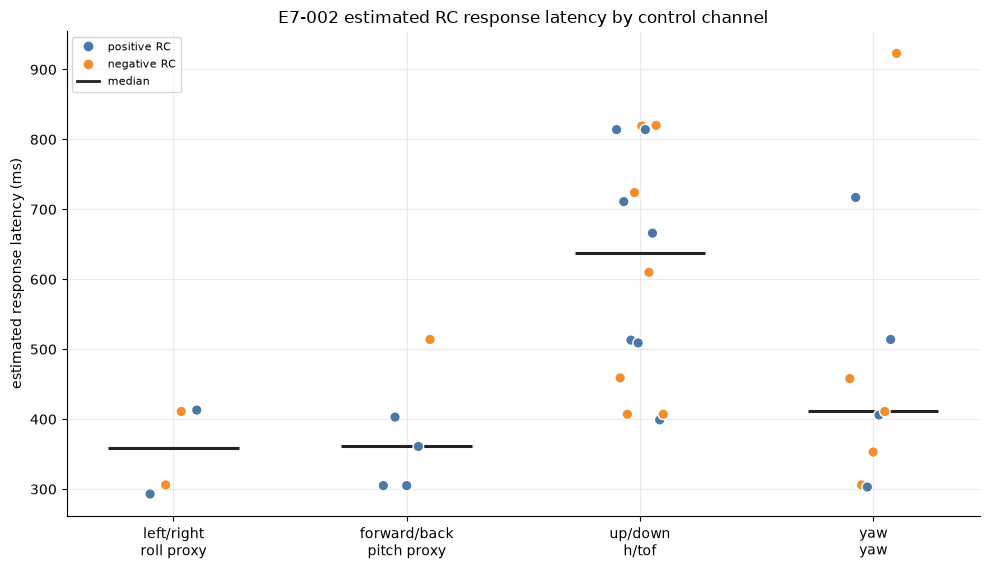

saved: notebooks/images/e7_rc_reaction_latency.png
RC response latency summary for E7-002:
axis | motion | proxy | valid/total pulses | median ms | mean ms | range ms | note
rc_a | left/right | roll | 4/7 | 358 | 356 | 293-413 | attitude proxy
rc_b | forward/back | pitch | 5/12 | 361 | 378 | 305-514 | attitude proxy
rc_c | up/down | h/tof | 14/14 | 638 | 619 | 399-820 | direct vertical distance
rc_d | yaw | yaw | 9/9 | 411 | 488 | 303-923 | direct yaw

Direct translational velocity check:
vgx min/max: -2/3 cm/s; vgy min/max: -2/2 cm/s
Because vgx/vgy stayed at zero, lateral and forward/back response latencies are reported from roll/pitch attitude proxies rather than from measured translation velocity.


In [244]:
def unique_rc_commands(state_rows):
    seen = OrderedDict()
    for r in state_rows:
        seq = r.get("rc_sequence", "")
        if seq == "":
            continue
        if seq not in seen:
            seen[seq] = r
    cmds = list(seen.values())
    cmds.sort(key=lambda r: to_float(r.get("rc_steady_elapsed_ms"), 0))
    return cmds


def rc_pulses(state_rows, axis, gap_ms=300.0):
    pulses = []
    active = None
    for row in state_rows:
        t = to_float(row.get("steady_elapsed_ms"))
        value = to_float(row.get(axis), 0)
        if math.isnan(t):
            continue
        sign = 1 if value > 0 else (-1 if value < 0 else 0)
        if sign == 0:
            if active is not None:
                active["end_ms"] = active["last_ms"]
                pulses.append(active)
                active = None
            continue
        if active is not None and active["sign"] == sign and t - active["last_ms"] <= gap_ms:
            active["last_ms"] = t
            active["end_ms"] = t
            active["samples"] += 1
        else:
            if active is not None:
                pulses.append(active)
            active = {"axis": axis, "sign": sign, "value": value, "start_ms": t, "end_ms": t, "last_ms": t, "samples": 1}
    if active is not None:
        pulses.append(active)
    return pulses


def median_before(samples, column, start_ms, window_ms=500.0):
    vals = [s[column] for s in samples if start_ms - window_ms <= s["t"] <= start_ms and not math.isnan(s[column])]
    if vals:
        return statistics.median(vals)
    for s in reversed(samples):
        if s["t"] <= start_ms and not math.isnan(s[column]):
            return s[column]
    return np.nan


def signed_angle_delta(value, baseline):
    return (value - baseline + 180.0) % 360.0 - 180.0


def estimate_rc_responses(state_rows, end_tolerance_ms=750.0):
    samples = []
    for row in state_rows:
        t = to_float(row.get("steady_elapsed_ms"))
        if math.isnan(t):
            continue
        samples.append({
            "t": t,
            "h": to_float(row.get("h")),
            "tof": to_float(row.get("tof")),
            "roll": to_float(row.get("roll")),
            "pitch": to_float(row.get("pitch")),
            "yaw": to_float(row.get("yaw")),
            "vgx": to_float(row.get("vgx")),
            "vgy": to_float(row.get("vgy")),
        })

    configs = {
        "rc_a": {"label": "left/right", "proxy": "roll", "threshold": 2.0, "unit": "deg", "expected": lambda sign: sign, "confidence": "attitude proxy"},
        "rc_b": {"label": "forward/back", "proxy": "pitch", "threshold": 2.0, "unit": "deg", "expected": lambda sign: -sign, "confidence": "attitude proxy"},
        "rc_d": {"label": "yaw", "proxy": "yaw", "threshold": 3.0, "unit": "deg", "expected": lambda sign: sign, "confidence": "direct yaw"},
    }

    responses = []
    for pulse in rc_pulses(state_rows, "rc_c"):
        start = pulse["start_ms"]
        limit = pulse["end_ms"] + end_tolerance_ms
        sign = pulse["sign"]
        base_h = median_before(samples, "h", start)
        base_tof = median_before(samples, "tof", start)
        for sample in samples:
            if sample["t"] < start or sample["t"] > limit:
                continue
            dh = (sample["h"] - base_h) * sign if not math.isnan(sample["h"]) and not math.isnan(base_h) else -np.inf
            dtof = (sample["tof"] - base_tof) * sign if not math.isnan(sample["tof"]) and not math.isnan(base_tof) else -np.inf
            if max(dh, dtof) >= 5.0:
                responses.append({
                    **pulse,
                    "label": "up/down",
                    "proxy": "h/tof",
                    "threshold": 5.0,
                    "unit": "cm",
                    "confidence": "direct vertical distance",
                    "response_ms": sample["t"],
                    "latency_ms": sample["t"] - start,
                    "delta": max(dh, dtof),
                })
                break

    for axis, cfg in configs.items():
        for pulse in rc_pulses(state_rows, axis):
            start = pulse["start_ms"]
            limit = pulse["end_ms"] + end_tolerance_ms
            sign = pulse["sign"]
            expected = cfg["expected"](sign)
            baseline = median_before(samples, cfg["proxy"], start)
            if math.isnan(baseline):
                continue
            for sample in samples:
                if sample["t"] < start or sample["t"] > limit:
                    continue
                value = sample[cfg["proxy"]]
                if math.isnan(value):
                    continue
                if cfg["proxy"] == "yaw":
                    delta = signed_angle_delta(value, baseline) * expected
                else:
                    delta = (value - baseline) * expected
                if delta >= cfg["threshold"]:
                    responses.append({
                        **pulse,
                        **cfg,
                        "response_ms": sample["t"],
                        "latency_ms": sample["t"] - start,
                        "delta": delta,
                    })
                    break
    responses.sort(key=lambda r: (r["axis"], r["start_ms"]))
    return responses


state_rows = get_state("E7-KBD-RESPONSE-002-state")
responses = estimate_rc_responses(state_rows)
axis_order = ["rc_a", "rc_b", "rc_c", "rc_d"]
axis_labels = {"rc_a": "left/right\nroll proxy", "rc_b": "forward/back\npitch proxy", "rc_c": "up/down\nh/tof", "rc_d": "yaw\nyaw"}
axis_colors = {"rc_a": "#4C78A8", "rc_b": "#72B7B2", "rc_c": "#F28E2B", "rc_d": "#E45756"}

fig, ax = plt.subplots(figsize=(10, 5.8))
for idx, axis in enumerate(axis_order, start=1):
    vals = [r["latency_ms"] for r in responses if r["axis"] == axis]
    signs = [r["sign"] for r in responses if r["axis"] == axis]
    if not vals:
        continue
    jitter = np.linspace(-0.10, 0.10, len(vals)) if len(vals) > 1 else np.array([0.0])
    colors = ["#4C78A8" if sign > 0 else "#F28E2B" for sign in signs]
    ax.scatter(np.full(len(vals), idx) + jitter, vals, c=colors, edgecolor="white", s=58, zorder=3)
    ax.hlines(np.median(vals), idx - 0.28, idx + 0.28, color="#222222", linewidth=2.2, label="median" if idx == 1 else None)
ax.set_xticks(range(1, len(axis_order) + 1), [axis_labels[a] for a in axis_order])
ax.set_ylabel("estimated response latency (ms)")
ax.set_title("E7-002 estimated RC response latency by control channel")
ax.legend(handles=[
    plt.Line2D([], [], marker="o", color="w", markerfacecolor="#4C78A8", markeredgecolor="white", markersize=8, label="positive RC"),
    plt.Line2D([], [], marker="o", color="w", markerfacecolor="#F28E2B", markeredgecolor="white", markersize=8, label="negative RC"),
    plt.Line2D([], [], color="#222222", linewidth=2, label="median"),
], fontsize=8)
savefig("e7_rc_reaction_latency.png")

print("RC response latency summary for E7-002:")
print("axis | motion | proxy | valid/total pulses | median ms | mean ms | range ms | note")
for axis in axis_order:
    total = len(rc_pulses(state_rows, axis))
    rows = [r for r in responses if r["axis"] == axis]
    vals = [r["latency_ms"] for r in rows]
    if vals:
        first = rows[0]
        print(f"{axis} | {first['label']} | {first['proxy']} | {len(vals)}/{total} | {np.median(vals):.0f} | {np.mean(vals):.0f} | {np.min(vals):.0f}-{np.max(vals):.0f} | {first['confidence']}")
    else:
        print(f"{axis} | -- | -- | 0/{total} | -- | -- | -- | no reliable response detected")

print("\nDirect translational velocity check:")
vgx = series(state_rows, "vgx")
vgy = series(state_rows, "vgy")
print(f"vgx min/max: {np.nanmin(vgx):.0f}/{np.nanmax(vgx):.0f} cm/s; vgy min/max: {np.nanmin(vgy):.0f}/{np.nanmax(vgy):.0f} cm/s")
print("Because vgx/vgy stayed at zero, lateral and forward/back response latencies are reported from roll/pitch attitude proxies rather than from measured translation velocity.")


### E7 Drone State Subplot Matrix

This matrix shows the main state variables around the real flight window only: from about 7 seconds before the telemetry-estimated takeoff start to about 7 seconds after the telemetry-estimated landing start. This keeps the physical flight context visible without spending plot space on the full idle pre/post-run data.


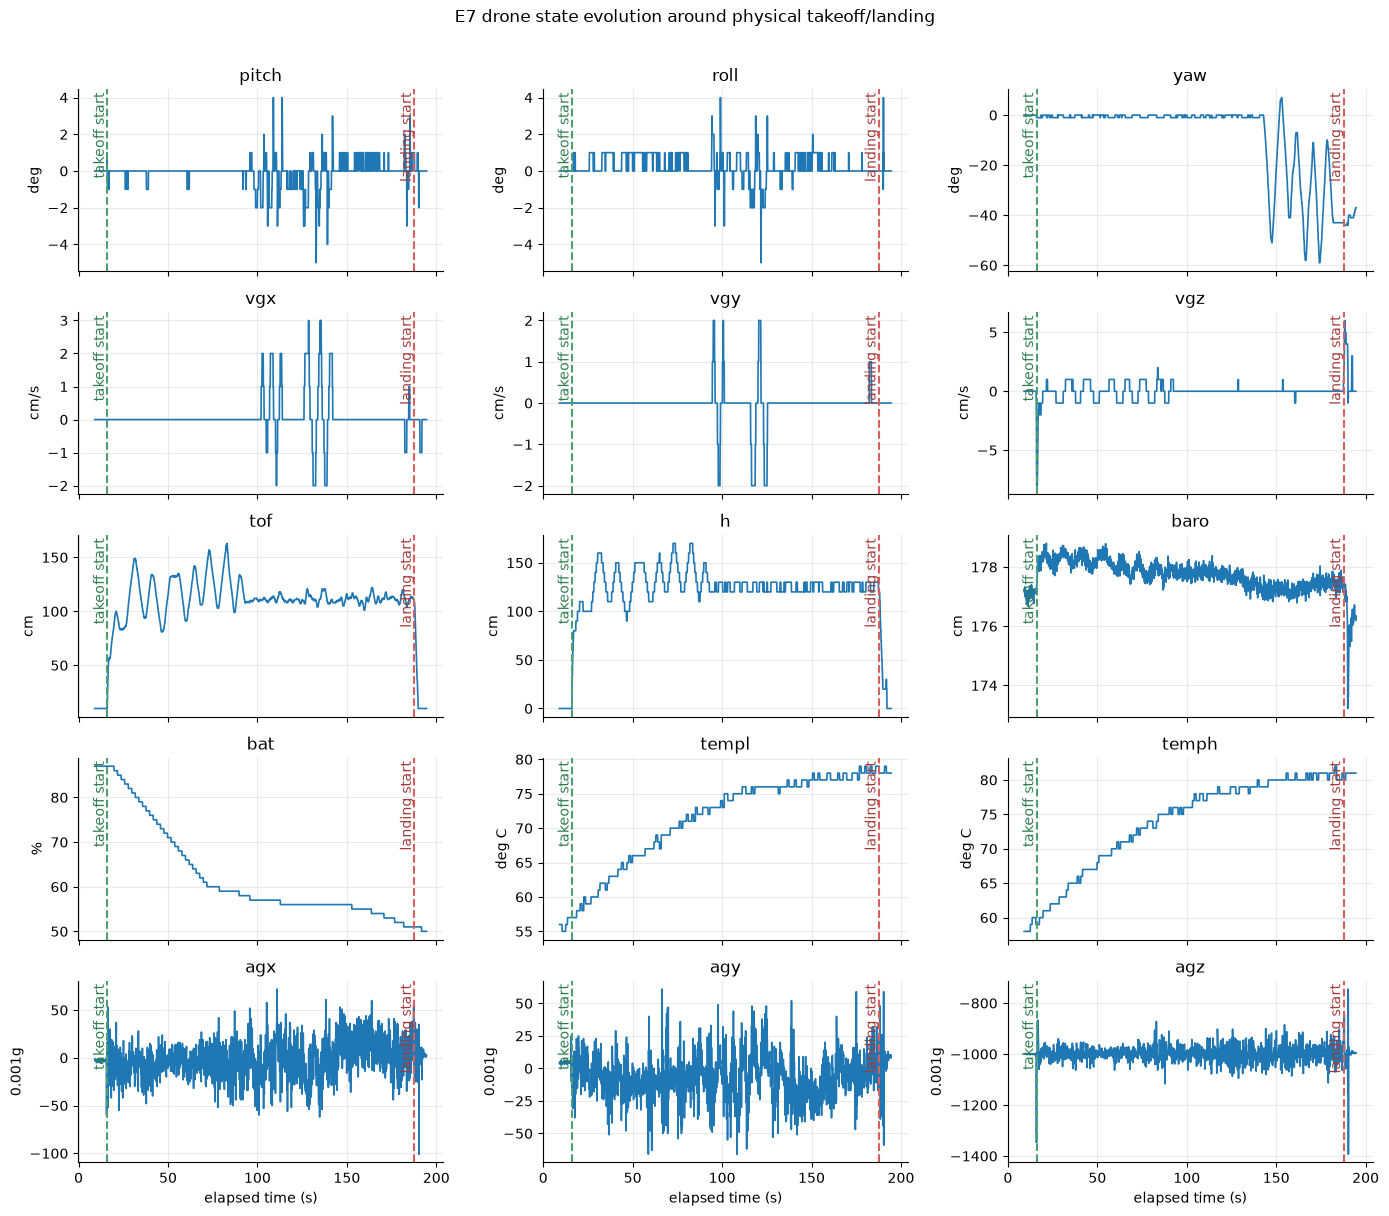

saved: notebooks/images/e7_drone_state_subplots.png
state subplot window: 9.0s to 194.7s
physical takeoff marker: 16.0s; physical landing marker: 187.7s; touchdown estimate: 192.2s


In [245]:
rows = get_state("E7-KBD-RESPONSE-002-state")
takeoff_s, land_s, touchdown_s = physical_flight_markers(rows)
window_start = max(0, takeoff_s - 7) if not math.isnan(takeoff_s) else 0
window_end = land_s + 7 if not math.isnan(land_s) else max(elapsed_seconds(rows))

x_all = series(rows, "steady_elapsed_ms", nonnegative=True) / 1000.0
state_cols = [
    ("pitch", "deg"), ("roll", "deg"), ("yaw", "deg"),
    ("vgx", "cm/s"), ("vgy", "cm/s"), ("vgz", "cm/s"),
    ("tof", "cm"), ("h", "cm"), ("baro", "cm"),
    ("bat", "%"), ("templ", "deg C"), ("temph", "deg C"),
    ("agx", "0.001g"), ("agy", "0.001g"), ("agz", "0.001g"),
]
fig, axes = plt.subplots(5, 3, figsize=(14, 12), sharex=True)
axes = axes.ravel()
for ax, (col, unit) in zip(axes, state_cols):
    y = series(rows, col)
    n = min(len(x_all), len(y))
    xm = x_all[:n]
    ym = y[:n]
    local_mask = (xm >= window_start) & (xm <= window_end)
    ax.plot(xm[local_mask], ym[local_mask], linewidth=1.2)
    annotate_takeoff_land(ax, takeoff_s, land_s)
    ax.set_title(col)
    ax.set_ylabel(unit)
    ax.grid(True, alpha=0.25)
for ax in axes[len(state_cols):]:
    ax.axis("off")
for ax in axes[-3:]:
    ax.set_xlabel("elapsed time (s)")
fig.suptitle("E7 drone state evolution around physical takeoff/landing", y=1.01)
savefig("e7_drone_state_subplots.png")
print(f"state subplot window: {window_start:.1f}s to {window_end:.1f}s")
print(f"physical takeoff marker: {takeoff_s:.1f}s; physical landing marker: {land_s:.1f}s; touchdown estimate: {touchdown_s:.1f}s")


## Recovery Evidence

The recovery plots show how freshness and connection-state indicators behaved during power-cycle and Wi-Fi-loss experiments. The quality score bands are the same as above: 100 means OK, 60 means degraded, and 0 means stale or no data.


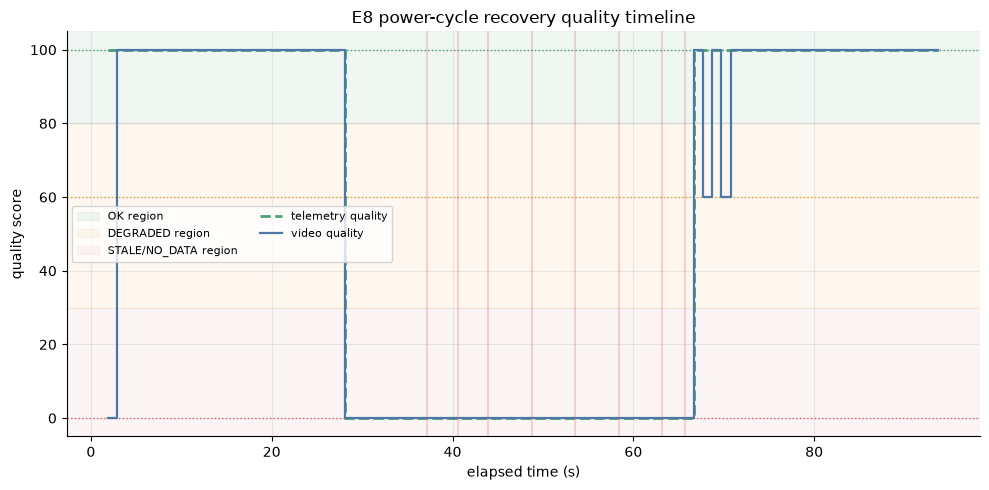

saved: notebooks/images/e8_power_cycle_quality.png


In [246]:
rows = get_rows("E8-PWR-CYCLE-001")
x_t, tq = xy_series(rows, "telemetry_quality_score", nonnegative=True)
x_v, vq = xy_series(rows, "video_quality_score", nonnegative=True)
fig, ax = plt.subplots(figsize=(10, 5))
add_quality_bands(ax)
ax.step(x_t, tq, where="post", label="telemetry quality", color="#4C9F70", linestyle="--", linewidth=2.0)
ax.step(x_v, vq, where="post", label="video quality", color="#4C78A8", linestyle="-", linewidth=1.6)
recovery_x = [to_float(r.get("elapsed_ms")) / 1000.0 for r in rows if to_int(r.get("recovery_attempted"), 0) == 1]
for rx in recovery_x:
    ax.axvline(rx, color="#D95F5F", alpha=0.25)
ax.set_xlabel("elapsed time (s)")
ax.set_ylabel("quality score")
ax.set_title("E8 power-cycle recovery quality timeline")
ax.legend(fontsize=8, ncol=2)
savefig("e8_power_cycle_quality.png")


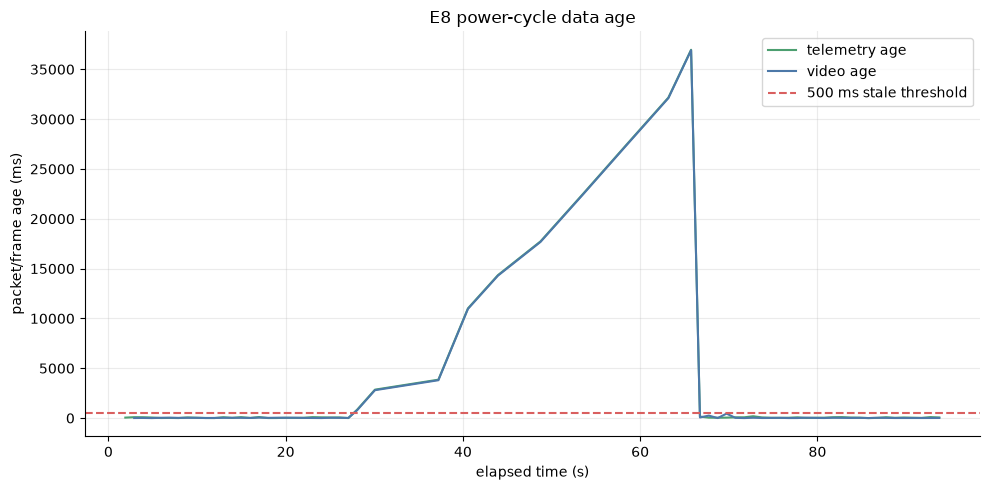

saved: notebooks/images/e8_power_cycle_age.png


In [247]:
rows = get_rows("E8-PWR-CYCLE-001")
tx, ty = xy_series(rows, "telemetry_age_ms", nonnegative=True)
vx, vy = xy_series(rows, "video_age_ms", nonnegative=True)
plt.figure(figsize=(10, 5))
plt.plot(tx, ty, label="telemetry age", color="#4C9F70")
plt.plot(vx, vy, label="video age", color="#4C78A8")
plt.axhline(500, color="#D95F5F", linestyle="--", label="500 ms stale threshold")
plt.xlabel("elapsed time (s)")
plt.ylabel("packet/frame age (ms)")
plt.title("E8 power-cycle data age")
plt.legend()
savefig("e8_power_cycle_age.png")


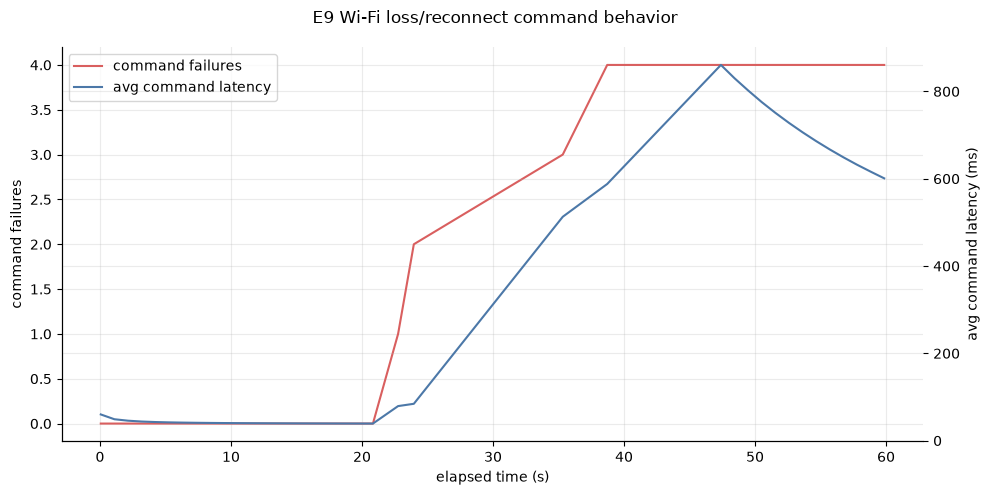

saved: notebooks/images/e9_wifi_loss_reconnect.png


In [248]:
rows = get_rows("E9-WIFI-LOSS-001")
x_fail, failures = xy_series(rows, "command_failures", nonnegative=True)
x_lat, latency = xy_series(rows, "command_latency_ms_avg", nonnegative=True)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(x_fail, failures, color="#D95F5F", label="command failures")
ax1.set_ylabel("command failures")
ax1.set_xlabel("elapsed time (s)")
ax2 = ax1.twinx()
ax2.plot(x_lat, latency, color="#4C78A8", label="avg command latency")
ax2.set_ylabel("avg command latency (ms)")
fig.suptitle("E9 Wi-Fi loss/reconnect command behavior")
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")
savefig("e9_wifi_loss_reconnect.png")


## Reproducibility Check

This final cell lists the generated image files. If a file is missing, rerun the notebook from the top.


In [249]:
expected = [
    "experiment_data_availability.png",
    "e2_command_latency.png",
    "telemetry_age_comparison.png",
    "telemetry_freshness_timeline.png",
    "video_decode_fps_comparison.png",
    "video_quality_comparison.png",
    "gui_tick_delay_idle_vs_flight.png",
    "e5_state_gaps.png",
    "e7_state_gaps.png",
    "e5_temperature.png",
    "e7_height_and_vertical_rc.png",
    "e7_rc_channels.png",
    "e7_rc_gap_histogram.png",
    "e7_operation_quality_video.png",
    "e7_rc_reaction_latency.png",
    "e7_drone_state_subplots.png",
    "e8_power_cycle_quality.png",
    "e8_power_cycle_age.png",
    "e9_wifi_loss_reconnect.png",
]
for name in expected:
    path = IMAGES_DIR / name
    print(f"{'OK' if path.exists() else 'MISSING'} {name}")


OK experiment_data_availability.png
OK e2_command_latency.png
OK telemetry_age_comparison.png
OK telemetry_freshness_timeline.png
OK video_decode_fps_comparison.png
OK video_quality_comparison.png
OK gui_tick_delay_idle_vs_flight.png
OK e5_state_gaps.png
OK e7_state_gaps.png
OK e5_temperature.png
OK e7_height_and_vertical_rc.png
OK e7_rc_channels.png
OK e7_rc_gap_histogram.png
OK e7_operation_quality_video.png
OK e7_rc_reaction_latency.png
OK e7_drone_state_subplots.png
OK e8_power_cycle_quality.png
OK e8_power_cycle_age.png
OK e9_wifi_loss_reconnect.png
